# 1&nbsp; Initialisation

## Imports

In [1]:
# Python standard library packages to do file/folder manipulations,
# pickle is a package to store python variables
import glob, os, pickle, time, h5py, sys, re
sys.path.append('Metabolism/VisualActivity/RHCVisualisation/RHCThermalPlots/RHCImaging')
sys.path.append('Metabolism/VisualActivity/RHCVisualisation/RHCThermalPlots')
sys.path.append('Metabolism/VisualActivity/RHCVisualisation')
sys.path.append('Metabolism/VisualActivity')
sys.path.append('Metabolism')


# this packages helps load and save .mat files older than v7
import hdf5storage

# numpy works with arrays, pandas used to work with fancy numpy arrays
import numpy as np
import pandas as pd
from IPython.display import Image
# matplotlib is used to plot and animate to make movies
import matplotlib.pyplot as plt

# Scikit-learn is a go-to library in Python for all things related to machine learning
from sklearn.decomposition import PCA
from Metabolism.libco2 import getExpDTs, MetabolicExp

from utils import plot_ethogram, download_dataset, reconstruct_whole_hive
%matplotlib inline

from dask.distributed import Client
# Start a client using all CPUs of this machine
client = Client()
client

distributed.diskutils - INFO - Found stale lock file and directory '/Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/dask-worker-space/worker-yljueevo', purging
distributed.diskutils - INFO - Found stale lock file and directory '/Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/dask-worker-space/worker-374p1lj0', purging
distributed.diskutils - INFO - Found stale lock file and directory '/Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/dask-worker-space/worker-u2o4oyxe', purging
distributed.diskutils - INFO - Found stale lock file and directory '/Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/dask-worker-space/worker-99k_vri0', purging


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 12,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:59016,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 12
Started: Just now,Total memory: 32.00 GiB
Comm: tcp://127.0.0.1:59033,Total threads: 3
Dashboard: http://127.0.0.1:59036/status,Memory: 8.00 GiB
Nanny: tcp://127.0.0.1:59022,


## Configuration

In [2]:
resolution = 600 # in seconds --> 10 minutes
whole_hive = True # Combine both ihls per hive (True) or keep them separate (False).
include_temperature = False # Whether to download/keep ambient temperature ('Tamb') at all.
WideNormalisation = True # Whether to normalise all data across datasets (True) or normalise each dataset independently (False)
projectPath = r"/Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindScaledVisualActivityWholeHiveNewTiming/"
save_files = True
force_reload = False # Whether to force reloading of the data or use the intermediate .pkl files if they exist
exps_list_imgs_loaded = ['SharpDay', 'SharpNight', 'SoftDay', 'SoftNight', 'Constant']
all_exps_list = ['SharpDay', 'SharpNight', 'SoftDay', 'SoftNight', 'Idle', 'Constant', 'Observation']
used_exp_list = all_exps_list # Select the experiments to use for ethogram generation
min_regions = 10 # Target number of watershed regions for the ethogram
use_bee_scaled_activity = True # Whether to scale "activity" by hive bee count (per bee_scale bees, using BeeCounter's estimates) or keep it as the raw fraction-of-pixels-moved metric
if use_bee_scaled_activity:
    bee_scale = 100 # Only used when use_bee_scaled_activity=True: scale the "activity" metric per this many bees (e.g. 100 -> pixels-moved per 100 bees)

## Dataset(s) loading

In [3]:
# Build set of required keys from used_exp_list (see config cell).
#
# exps_ihls only says which hive(s) ran an experiment, not which ihls have data -- CO2,
# humidity, activity and Tamb aren't tied to the cluster's ihl, so both 'upper' and 'lower'
# are fetched unless the full per-sensor thermal grid is needed (only_amb_T=False, not an
# option here -- only_ambT is fixed below just to keep this conditional correct if that changes).
only_ambT = True
needs_cluster_ihl = include_temperature and not only_ambT

# key = (exp, hive_nb, ihl) if whole_hive=False, else (exp, hive_nb).
intermediate_dir = "Results/Intermediate_Results"


def _source_id(key):
    if whole_hive:
        exp, hive_nb = key
        return f"{exp}_hive{hive_nb}"
    else:
        exp, hive_nb, ihl = key
        return f"{exp}_hive{hive_nb}_{ihl}"


# Human-readable labels for plot titles/subtitles: the paper uses "Abrupt"/"Gradual"
# heating terminology instead of the internal "Sharp"/"Soft" condition names used for
# dataset/file ids.
_EXP_DISPLAY_NAMES = {
    "SharpDay": "Abrupt Day Heating",
    "SharpNight": "Abrupt Night Heating",
    "SoftDay": "Gradual Day Heating",
    "SoftNight": "Gradual Night Heating",
}


def _pretty_label(key):
    exp, hive_nb = key[0], key[1]
    label = f"{_EXP_DISPLAY_NAMES.get(exp, exp)} - Hive {hive_nb}"
    if len(key) > 2 and key[2]:
        label += f" ({key[2]})"
    return label


required_keys = set()
skipped_no_whole_hive = []
for exp in used_exp_list:
    exps_ihls_entry = MetabolicExp.exps_ihls.get(exp)
    hives_used = [int(h[-1]) for h in exps_ihls_entry.keys() if exps_ihls_entry.get(h)]
    for hive_nb in hives_used:
        cluster_ihls = [ihl for ihl in (exps_ihls_entry.get(f'hive{hive_nb}', []) or []) if ihl]
        if whole_hive:
            if needs_cluster_ihl and set(cluster_ihls) != {'upper', 'lower'}:
                skipped_no_whole_hive.append((exp, hive_nb, cluster_ihls))
            else:
                required_keys.add((exp, hive_nb))
        else:
            ihls_to_fetch = cluster_ihls if needs_cluster_ihl else ['upper', 'lower']
            for ihl in ihls_to_fetch:
                required_keys.add((exp, hive_nb, ihl))

if needs_cluster_ihl and skipped_no_whole_hive:
    print(f"Skipping {len(skipped_no_whole_hive)} (experiment, hive) pair(s) without both ihls' thermal data:")
    for exp, hive_nb, cluster_ihls in skipped_no_whole_hive:
        print(f"  {exp} hive{hive_nb}: cluster was only in {cluster_ihls}")

# Columns needed for the current config; cache reuse below just checks these are present.
needed_cols = ["co2_UL", "co2_UR", "co2_LL", "co2_LR"] if whole_hive else ["co2_L", "co2_R"]
needed_cols += ["rel_humid"]
if include_temperature:
    needed_cols += ["Tamb"]
needed_cols += ["activity"]

exps_dfs = {}
missing_keys = set(required_keys)

if not force_reload:
    for key in sorted(required_keys):
        source_id = _source_id(key)
        pkl_path = os.path.join(intermediate_dir, f"{source_id}.pkl")
        cached_df = None
        if os.path.exists(pkl_path):
            with open(pkl_path, 'rb') as f:
                cached_df = pickle.load(f)
        elif whole_hive:
            # Reconstruct from cached upper/lower pickles instead of re-downloading, if both exist.
            exp, hive_nb = key
            upper_path = os.path.join(intermediate_dir, f"{exp}_hive{hive_nb}_upper.pkl")
            lower_path = os.path.join(intermediate_dir, f"{exp}_hive{hive_nb}_lower.pkl")
            if os.path.exists(upper_path) and os.path.exists(lower_path):
                with open(upper_path, 'rb') as f:
                    upper_df = pickle.load(f)
                with open(lower_path, 'rb') as f:
                    lower_df = pickle.load(f)
                cached_df = reconstruct_whole_hive(upper_df, lower_df, only_amb_T=True)
                print(f"Reconstructed {source_id} from cached {exp}_hive{hive_nb}_upper/lower pickles.")

        if cached_df is not None and set(needed_cols).issubset(cached_df.columns):
            exps_dfs[key] = cached_df[needed_cols]
            missing_keys.discard(key)
            print(f"Loaded {source_id} from pickle {exps_dfs[key].shape}.")
else:
    print("force_reload is True: skipping the pickle cache, downloading all datasets.")

if missing_keys:
    print(f"Downloading {len(missing_keys)} missing dataset(s): {sorted(missing_keys)}")
    for key in sorted(missing_keys):
        exp, hive_nb = key[0], key[1]
        ihl = None if whole_hive else key[2]
        source_id = _source_id(key)
        bucket = MetabolicExp.buckets_by_type[exp]
        start_ts, end_ts = getExpDTs(exp, hive_nb)
        imgs_path = MetabolicExp.imgs_paths_by_type[exp]
        print(f"Downloading dataset for experiment: {exp}, hive: {hive_nb}, IHL: {'whole hive' if whole_hive else ihl}")
        df_exp = download_dataset(hive_nb=hive_nb, ihl=ihl,
                                resolution=resolution,
                                start_ts=start_ts,
                                end_ts=end_ts,
                                only_amb_T=True,
                                visualActivityPath=imgs_path,
                                bucket=bucket,
                                whole_hive=whole_hive)
        print(f"Data shape: {df_exp.shape}")
        print(df_exp.head())
        exps_dfs[key] = df_exp[needed_cols]
else:
    print("All required datasets were loaded from their pickle files.")

Loaded Constant_hive2 from pickle (419, 6).
Loaded Idle_hive1 from pickle (1475, 6).
Loaded Idle_hive2 from pickle (1351, 6).
Loaded Observation_hive1 from pickle (7232, 6).
Loaded Observation_hive2 from pickle (3491, 6).
Loaded SharpDay_hive1 from pickle (1526, 6).
Loaded SharpDay_hive2 from pickle (1233, 6).
Loaded SharpNight_hive1 from pickle (1988, 6).
Loaded SharpNight_hive2 from pickle (981, 6).
Loaded SoftDay_hive1 from pickle (1871, 6).
Loaded SoftDay_hive2 from pickle (1217, 6).
Loaded SoftNight_hive1 from pickle (2193, 6).
All required datasets were loaded from their pickle files.


In [4]:
if save_files:
    # Store each dataset as its own pickle file (Results/Intermediate_Results/{exp}_hive{hive_nb}_{ihl}.pkl)
    # so a future run with force_reload=False can reload whichever datasets are already cached
    # and only re-download the rest (see the loading cell above). If a file already exists,
    # merge the new data with the existing data and overwrite the file in place.
    intermediate_dir = "Results/Intermediate_Results"
    os.makedirs(intermediate_dir, exist_ok=True)
    for key, df_exp in exps_dfs.items():
        source_id = _source_id(key)
        pkl_path = os.path.join(intermediate_dir, f"{source_id}.pkl")
        existing_df = None
        if os.path.exists(pkl_path):
            with open(pkl_path, 'rb') as f:
                existing_df = pickle.load(f)
            # Merge the new data with the existing data, adding columns to the df if they don't already exist
            for col in df_exp.columns:
                if col not in existing_df.columns:
                    existing_df[col] = df_exp[col]
            # Overwrite the existing pickle file with the merged dataframe
            with open(pkl_path, 'wb') as f:
                pickle.dump(existing_df, f)
            print(f"Merged and saved a dataset to {intermediate_dir}/")
        else:
            with open(pkl_path, 'wb') as f:
                pickle.dump(df_exp, f)
            print(f"Saved a dataset to {intermediate_dir}/")

Merged and saved a dataset to Results/Intermediate_Results/
Merged and saved a dataset to Results/Intermediate_Results/
Merged and saved a dataset to Results/Intermediate_Results/
Merged and saved a dataset to Results/Intermediate_Results/
Merged and saved a dataset to Results/Intermediate_Results/
Merged and saved a dataset to Results/Intermediate_Results/
Merged and saved a dataset to Results/Intermediate_Results/
Merged and saved a dataset to Results/Intermediate_Results/
Merged and saved a dataset to Results/Intermediate_Results/
Merged and saved a dataset to Results/Intermediate_Results/
Merged and saved a dataset to Results/Intermediate_Results/
Merged and saved a dataset to Results/Intermediate_Results/


In [5]:
# full_dts stores the full data range for all datasets
full_dts = {}
for key, df in exps_dfs.items():
    full_dts[key] = pd.date_range(df.index.min(), df.index.max(), freq='10min')
print("Full data ranges for all datasets:")
for key, dts in full_dts.items():
    print(f"Dataset {key}: {dts.min()} to {dts.max()}")

Full data ranges for all datasets:
Dataset ('Constant', 2): 2024-11-19 18:20:00+00:00 to 2024-11-22 16:00:00+00:00
Dataset ('Idle', 1): 2024-11-12 06:00:00+00:00 to 2024-11-22 16:00:00+00:00
Dataset ('Idle', 2): 2024-11-09 23:00:00+00:00 to 2024-11-19 08:00:00+00:00
Dataset ('Observation', 1): 2024-09-04 16:00:00+00:00 to 2024-10-28 08:40:00+00:00
Dataset ('Observation', 2): 2024-10-02 19:00:00+00:00 to 2024-10-28 08:40:00+00:00
Dataset ('SharpDay', 1): 2024-12-06 15:40:00+00:00 to 2024-12-17 10:20:00+00:00
Dataset ('SharpDay', 2): 2024-11-27 22:00:00+00:00 to 2024-12-06 15:40:00+00:00
Dataset ('SharpNight', 1): 2024-11-22 16:10:00+00:00 to 2024-12-06 15:40:00+00:00
Dataset ('SharpNight', 2): 2024-12-06 15:40:00+00:00 to 2024-12-13 11:00:00+00:00
Dataset ('SoftDay', 1): 2025-01-06 16:20:00+00:00 to 2025-01-19 16:00:00+00:00
Dataset ('SoftDay', 2): 2024-12-24 17:20:00+00:00 to 2025-01-02 04:00:00+00:00
Dataset ('SoftNight', 1): 2024-12-19 10:40:00+00:00 to 2025-01-03 16:00:00+00:00


In [6]:
exps_dfs_interpolated = exps_dfs.copy()
# First linearly interpolate any NaN values that may exist in the dataframes over 3 rows, beyond that leave them as NaN
for key, df in exps_dfs_interpolated.items():
    len_before = len(df)
    df = df.astype(float)
    nans_before = int(df.isna().sum().sum())
    df.interpolate(method='time', limit=3, limit_direction='both', inplace=True)
    nans_after = int(df.isna().sum().sum())
    exps_dfs_interpolated[key] = df
    print(f"Interpolated {nans_before - nans_after} NaN cells for dataset {key}. Remaining NaN cells: {nans_after}. Remaining lines: {len(df)}")

# Drop any NaN values that may still exist after resampling
exps_dfs_dropna = exps_dfs_interpolated.copy()
for key, df in exps_dfs_dropna.items():
    len_before = len(df)
    rows_with_nan_before = int(df.isna().any(axis=1).sum())
    df = df.dropna(how='any')
    exps_dfs_dropna[key] = df
    print(f"Dropped {len_before - len(df)} rows with NaN values for dataset {key}. Rows with NaN before drop: {rows_with_nan_before}. Remaining lines: {len(df)}")

Interpolated 3 NaN cells for dataset ('Constant', 2). Remaining NaN cells: 0. Remaining lines: 419
Interpolated 17 NaN cells for dataset ('Idle', 1). Remaining NaN cells: 0. Remaining lines: 1475
Interpolated 20 NaN cells for dataset ('Idle', 2). Remaining NaN cells: 0. Remaining lines: 1351
Interpolated 164 NaN cells for dataset ('Observation', 1). Remaining NaN cells: 5250. Remaining lines: 7232
Interpolated 74 NaN cells for dataset ('Observation', 2). Remaining NaN cells: 2097. Remaining lines: 3491
Interpolated 5 NaN cells for dataset ('SharpDay', 1). Remaining NaN cells: 2. Remaining lines: 1526
Interpolated 30 NaN cells for dataset ('SharpDay', 2). Remaining NaN cells: 2. Remaining lines: 1233
Interpolated 2 NaN cells for dataset ('SharpNight', 1). Remaining NaN cells: 0. Remaining lines: 1988
Interpolated 39 NaN cells for dataset ('SharpNight', 2). Remaining NaN cells: 0. Remaining lines: 981
Interpolated 284 NaN cells for dataset ('SoftDay', 1). Remaining NaN cells: 19. Remaini

In [7]:
# Scale "activity" (fraction of pixels that moved) by each hive's estimated bee
# population, so the metric reflects movement per bee rather than being confounded by
# how many bees are even in the hive (population drops steadily over these winter
# experiments). Uses the hive-level population estimates from
# BeeCounter/bee_count_estimator.py, built from manually-labeled image counts.
# Controlled by use_bee_scaled_activity (see Configuration cell); when False, "activity"
# is left untouched as the raw metric.
if use_bee_scaled_activity:
    sys.path.append('Metabolism/VisualActivity/RHCVisualisation/RHCImaging/BeeCounter')
    from bee_count_estimator import HiveBeeCountEstimator

    bee_estimator = HiveBeeCountEstimator()

    exps_dfs_bee_scaled = {}
    for key, df in exps_dfs_dropna.items():
        hive_nb = key[1]
        df = df.copy()

        hive_sessions = bee_estimator.corrected_estimates(hive=hive_nb)
        if hive_sessions.empty:
            print(f"Dataset {key}: no labeled bee-count sessions for hive {hive_nb} -- dropping (can't scale activity).")
            continue

        # Outside the labeled session range, np.interp holds the nearest known value flat
        # (its default left/right behaviour) rather than extrapolating a trend -- i.e. we
        # assume the population stayed constant (no births/deaths) before the first / after
        # the last labeled session.
        first_ts, last_ts = hive_sessions["timestamp"].iloc[0], hive_sessions["timestamp"].iloc[-1]
        n_outside = int(((df.index < first_ts) | (df.index > last_ts)).sum())
        if n_outside:
            print(f"Dataset {key}: {n_outside}/{len(df)} rows fall outside the labeled bee-count range ({first_ts} to {last_ts}) -- holding the nearest labeled count constant for those.")

        known_x = hive_sessions["timestamp"].astype("int64").to_numpy()
        known_y = hive_sessions["corrected_total_bees"].to_numpy()
        bee_counts = np.interp(df.index.astype("int64"), known_x, known_y)

        df["activity"] = df["activity"] / (bee_counts / bee_scale)
        exps_dfs_bee_scaled[key] = df

    n_before = len(exps_dfs_dropna)
    exps_dfs_dropna = exps_dfs_bee_scaled
    print(f"Bee-scaled activity computed for {len(exps_dfs_dropna)}/{n_before} datasets (activity is now per {bee_scale} bees).")
else:
    print("use_bee_scaled_activity is False -- keeping 'activity' as the raw fraction-of-pixels-moved metric.")

Dataset ('Observation', 1): 2565/4173 rows fall outside the labeled bee-count range (2024-10-15 04:00:00+00:00 to 2025-01-12 04:20:00+00:00) -- holding the nearest labeled count constant for those.
Dataset ('Observation', 2): 637/1987 rows fall outside the labeled bee-count range (2024-10-16 04:20:00+00:00 to 2024-12-29 12:00:00+00:00) -- holding the nearest labeled count constant for those.
Dataset ('SoftDay', 1): 1070/1852 rows fall outside the labeled bee-count range (2024-10-15 04:00:00+00:00 to 2025-01-12 04:20:00+00:00) -- holding the nearest labeled count constant for those.
Dataset ('SoftDay', 2): 528/1157 rows fall outside the labeled bee-count range (2024-10-16 04:20:00+00:00 to 2024-12-29 12:00:00+00:00) -- holding the nearest labeled count constant for those.
Bee-scaled activity computed for 12/12 datasets (activity is now per 100 bees).


Raw Data Plots

In [8]:
# Pick a dataset to showcase below: prefer Observation hive2 if present, else the first one.
_preferred_key = ('Observation', 2) if whole_hive else ('Observation', 2, 'upper')
_plot_key = _preferred_key if _preferred_key in exps_dfs_dropna else next(iter(exps_dfs_dropna))
df_plots = exps_dfs_dropna[_plot_key].copy()
print(f"Showing raw-data plots for dataset: {_plot_key}")

Showing raw-data plots for dataset: ('Observation', 2)


No 'Tamb' column in df_plots (include_temperature=False) -- skipping the temperature plot.


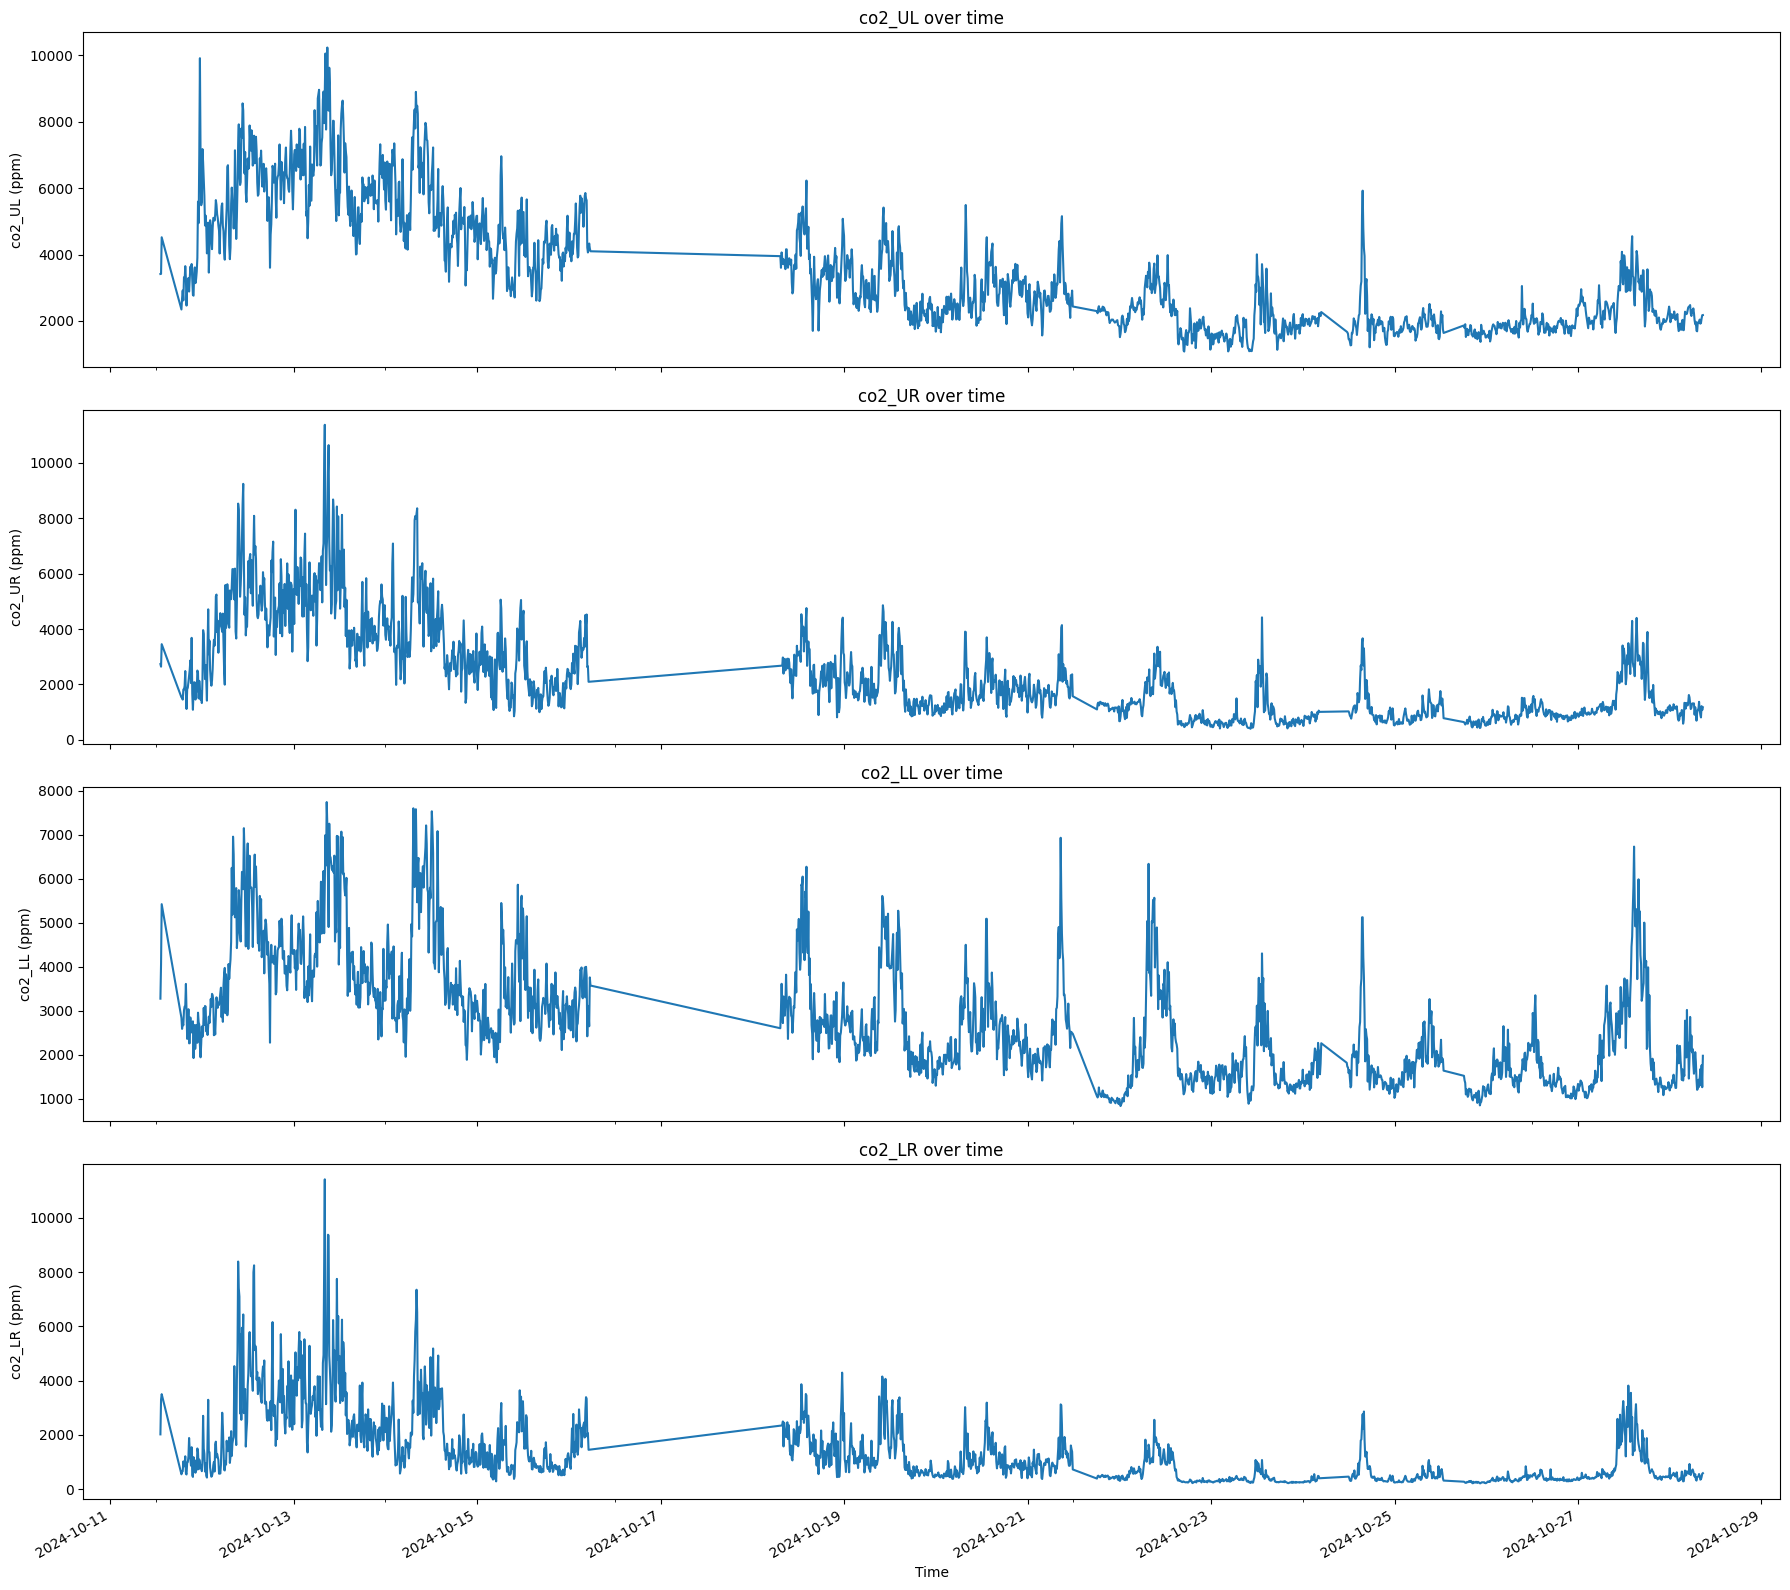

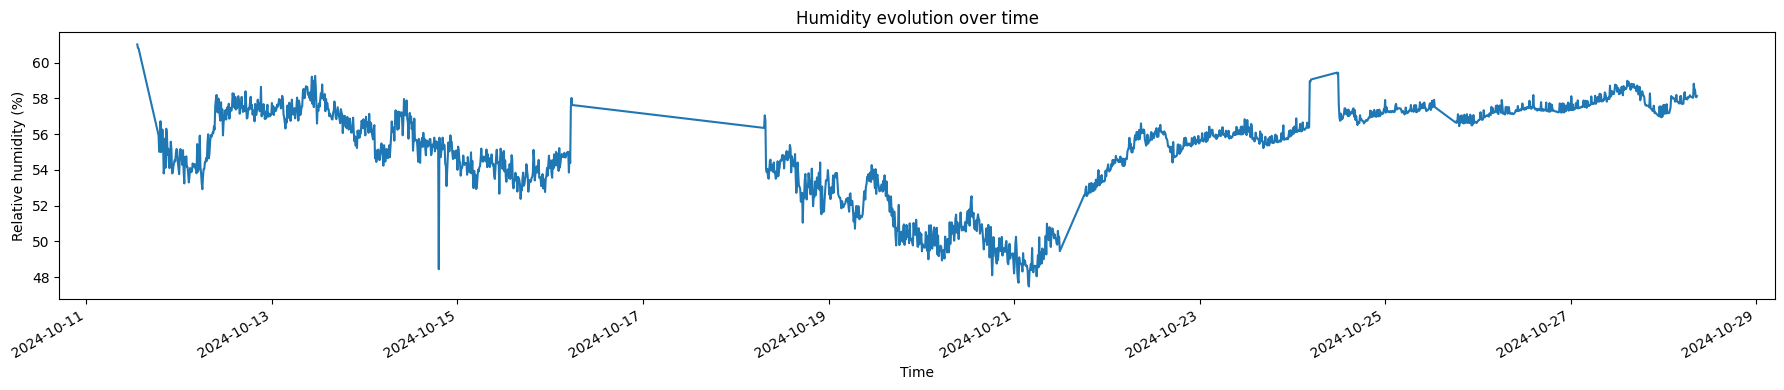

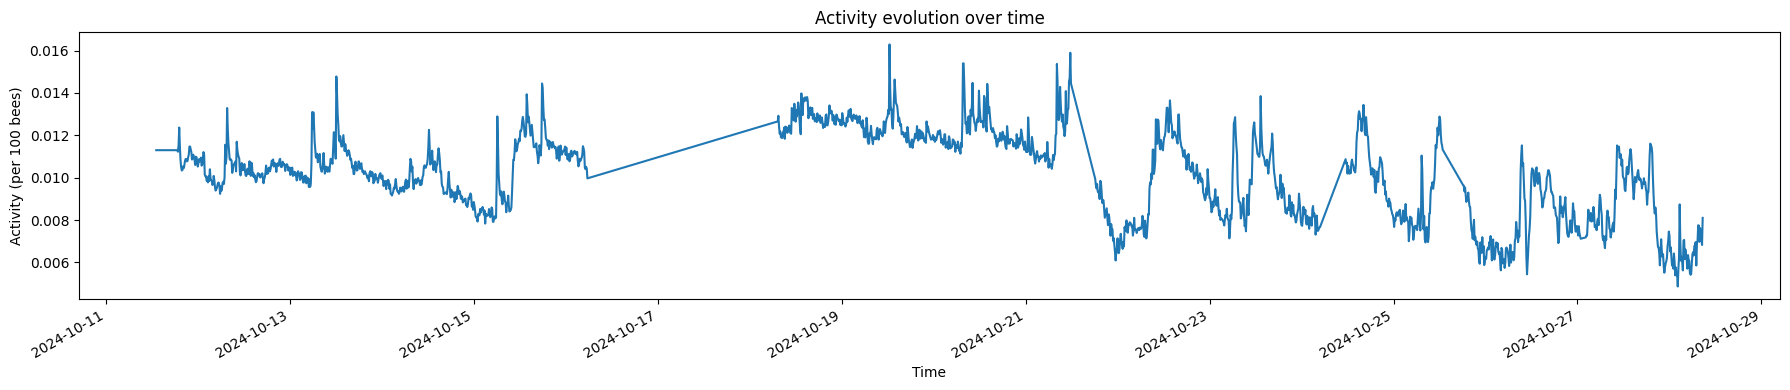

In [9]:
# --- Columns ---
co2_col = ["co2_UL", "co2_UR", "co2_LL", "co2_LR"] if whole_hive else ["co2_L", "co2_R"]
humid_col = "rel_humid"

# =========================
# 1) Ambient temperature over time (separate figure)
# =========================
if "Tamb" in df_plots.columns:
    ax = df_plots["Tamb"].plot(figsize=(18, 4))
    ax.set_xlabel("Time")
    ax.set_ylabel("Ambient temperature (°C)")
    ax.set_title("Ambient temperature evolution over time")
    plt.tight_layout()
    plt.show()
else:
    print("No 'Tamb' column in df_plots (include_temperature=False) -- skipping the temperature plot.")

# =========================
# 2) CO2 over time (separate figure)
# =========================
# One row per CO2 sensor, sharing the same x-axis
fig, axs = plt.subplots(nrows=len(co2_col), ncols=1, figsize=(18, 4 * len(co2_col)), sharex=True)
if len(co2_col) == 1:
    axs = [axs]
for ax, col in zip(axs, co2_col):
    df_plots[col].plot(ax=ax, title=f'{col} over time')
    ax.set_ylabel(f"{col} (ppm)")
axs[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

# =========================
# 3) Humidity over time (separate figure)
# =========================
ax = df_plots[humid_col].plot(figsize=(18, 4))
ax.set_xlabel("Time")
ax.set_ylabel("Relative humidity (%)")
ax.set_title("Humidity evolution over time")
plt.tight_layout()
plt.show()


# =========================
# 4) Activity over time (separate figure)
# =========================
if "activity" in df_plots.columns:
    if use_bee_scaled_activity:
        activity_plot = df_plots.loc[:, 'activity']
        activity_ylabel = f"Activity (per {bee_scale} bees)"
    else:
        activity_plot = df_plots.loc[:, 'activity'] * 100
        activity_ylabel = "Activity (%)"
    ax = activity_plot.plot(figsize=(18, 4))
    ax.set_xlabel("Time")
    ax.set_ylabel(activity_ylabel)
    ax.set_title("Activity evolution over time")
    plt.tight_layout()
    plt.show()

## Data availability checking

Total datapoints across all datasets: 19678
Datapoints taken into account (>=24h): 18106
Percentage of datapoints taken into account: 92.01%

Dataset ('Constant', 2):
Total datapoints: 419
Datapoints taken into account (>=24h): 419
Percentage of datapoints taken into account: 100.00%

First timestamp: 2024-11-19 18:20:00+00:00
Last timestamp: 2024-11-22 16:00:00+00:00

Dataset ('Idle', 1):
Total datapoints: 1475
Datapoints taken into account (>=24h): 1475
Percentage of datapoints taken into account: 100.00%

First timestamp: 2024-11-12 06:00:00+00:00
Last timestamp: 2024-11-22 16:00:00+00:00

Dataset ('Idle', 2):
Total datapoints: 1351
Datapoints taken into account (>=24h): 1351
Percentage of datapoints taken into account: 100.00%

First timestamp: 2024-11-09 23:00:00+00:00
Last timestamp: 2024-11-19 08:00:00+00:00

Dataset ('Observation', 1):
Total datapoints: 4173
Datapoints taken into account (>=24h): 3717
Percentage of datapoints taken into account: 89.07%

First timestamp: 2024-09

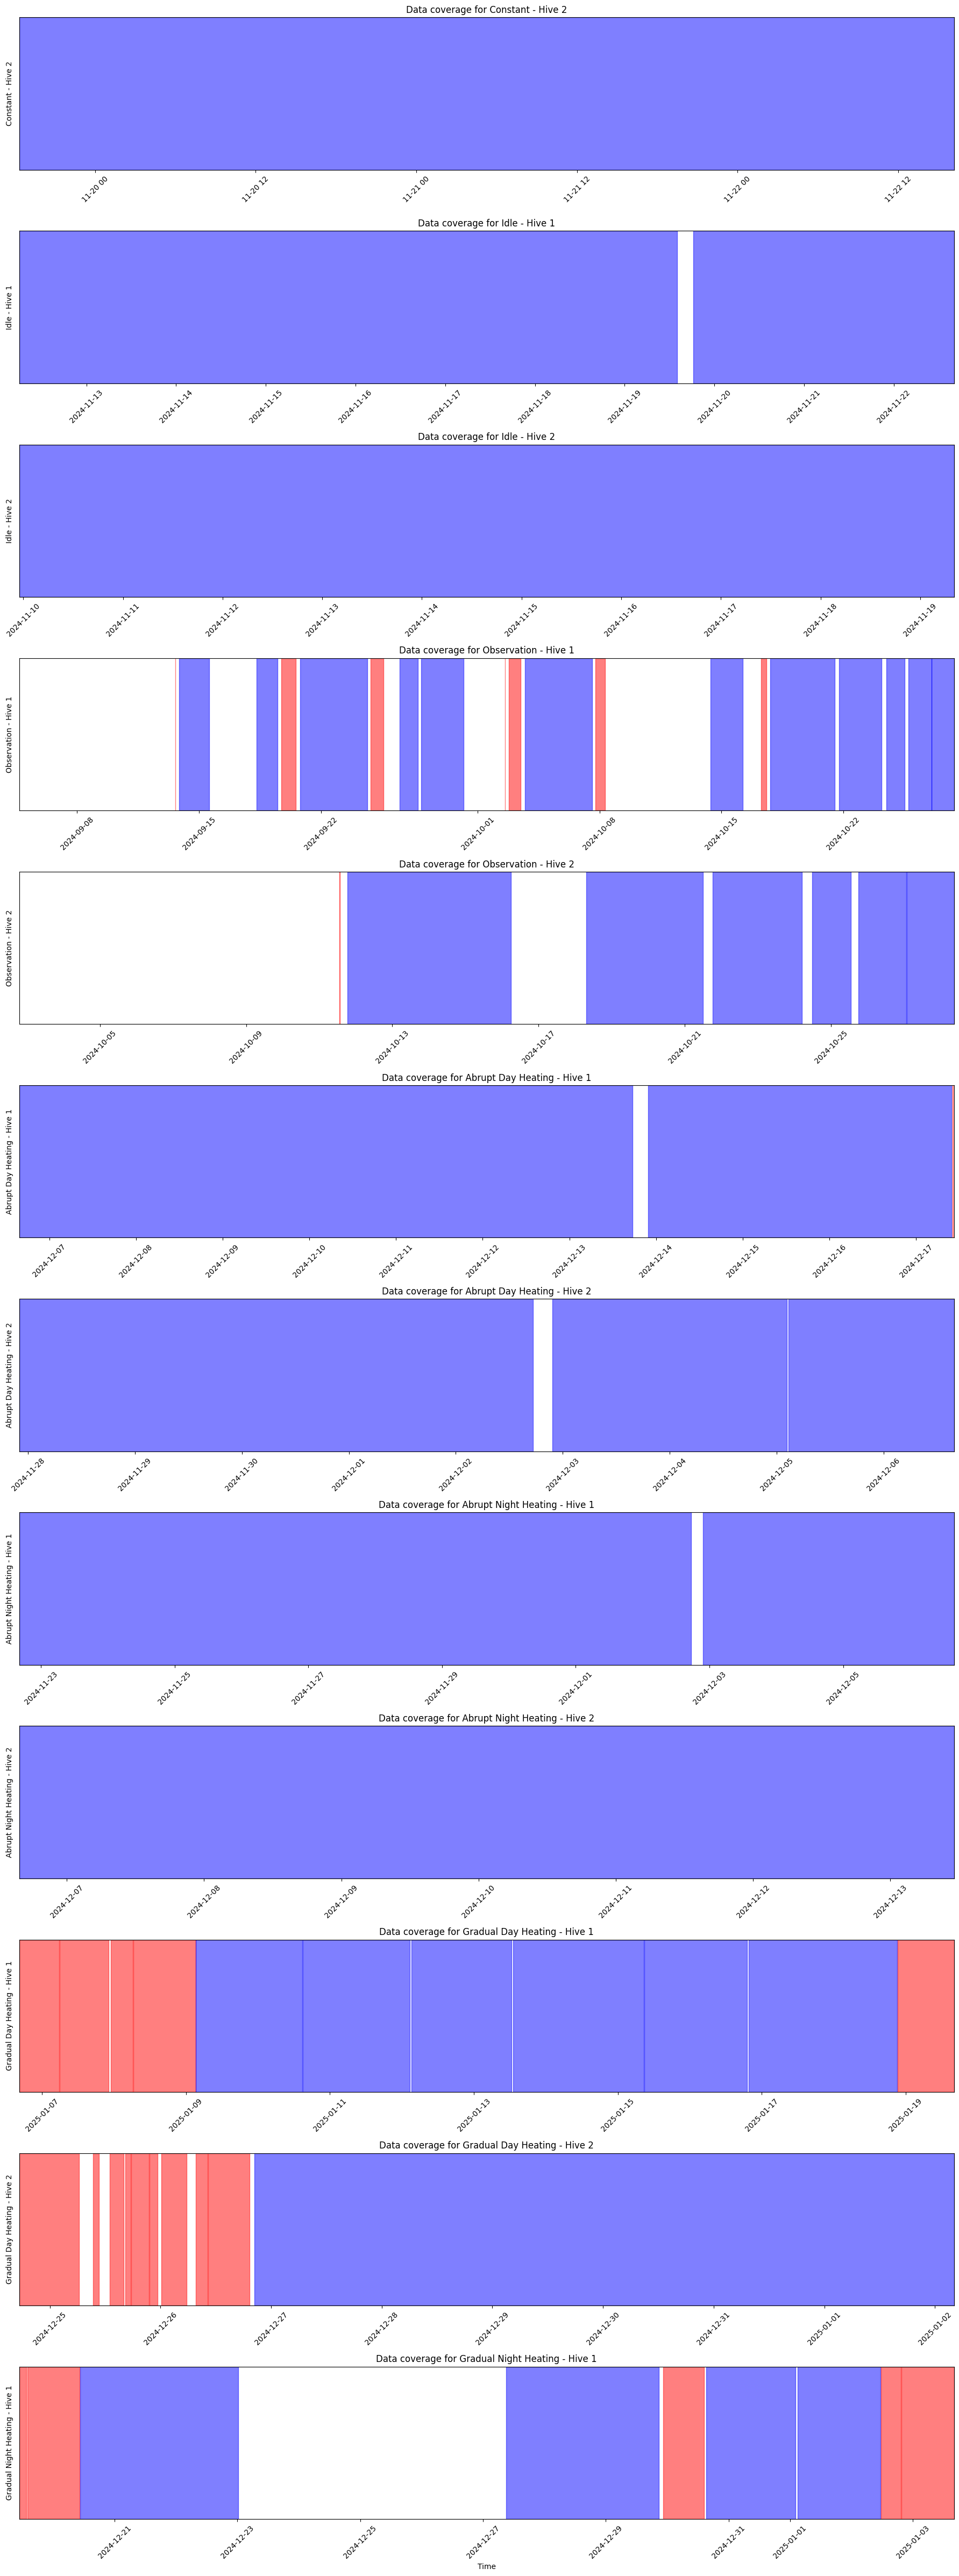

In [10]:
# Use full_dts as x-axis; color contiguous data chunks blue if >=24h, else red.

step = pd.Timedelta(seconds=resolution)
threshold = pd.Timedelta(hours=24)

n_rows = len(exps_dfs_dropna)
fig_height = 4 * n_rows  # Adjust height based on number of datasets
fig, axs = plt.subplots(nrows=n_rows, ncols=1, figsize=(18, fig_height), sharex=False)

for i,(key, df) in enumerate(exps_dfs_dropna.items()):
    full_dt = pd.DatetimeIndex(full_dts[key])
    mask = full_dt.isin(df.index)

    # find contiguous True runs in mask
    runs = []
    in_run = False
    for idx, val in enumerate(mask):
        if val and not in_run:
            run_start = idx
            in_run = True
        elif not val and in_run:
            run_end = idx - 1
            runs.append((run_start, run_end))
            in_run = False
    if in_run:
        runs.append((run_start, len(mask) - 1))

    # draw spans on the full_dts axis
    for start, end in runs:
        duration = (end - start + 1) * step
        color = 'blue' if duration >= threshold else 'red'
        start_dt = full_dt[start].to_pydatetime()
        end_dt = (full_dt[end] + step).to_pydatetime()
        axs[i].axvspan(start_dt, end_dt, color=color, alpha=0.5)

    axs[i].set_ylabel(_pretty_label(key))
    axs[i].set_ylim(0, 1)
    axs[i].set_yticks([])
    axs[i].set_title(f"Data coverage for {_pretty_label(key)}")
    axs[i].set_xlim(full_dt[0].to_pydatetime(), (full_dt[-1] + step).to_pydatetime())
    axs[i].tick_params(axis='x', rotation=45)

axs[-1].set_xlabel("Time")
plt.tight_layout()

# Print how much datapoints exist in total over all 3 datasets (blue + red) and what percentage are taken into account (blue/(blue + red))
total_points = sum(len(df) for df in exps_dfs_dropna.values())
# Count blue points (>=24h) and red points (<24h)
blue_points = 0
for key, df in exps_dfs_dropna.items():
    full_dt = pd.DatetimeIndex(full_dts[key])
    mask = full_dt.isin(df.index)

    # find contiguous True runs in mask
    runs = []
    in_run = False
    for idx, val in enumerate(mask):
        if val and not in_run:
            run_start = idx
            in_run = True
        elif not val and in_run:
            run_end = idx - 1
            runs.append((run_start, run_end))
            in_run = False
    if in_run:
        runs.append((run_start, len(mask) - 1))

    # count blue points (>=24h)
    for start, end in runs:
        duration = (end - start + 1) * step
        if duration >= threshold:
            blue_points += (end - start + 1)

print(f"Total datapoints across all datasets: {total_points}")
print(f"Datapoints taken into account (>=24h): {blue_points}")
print(f"Percentage of datapoints taken into account: {blue_points / total_points * 100:.2f}%\n")

# Same as above but per dataset
for key, df in exps_dfs_dropna.items():
    full_dt = pd.DatetimeIndex(full_dts[key])
    mask = full_dt.isin(df.index)

    # find contiguous True runs in mask
    runs = []
    in_run = False
    for idx, val in enumerate(mask):
        if val and not in_run:
            run_start = idx
            in_run = True
        elif not val and in_run:
            run_end = idx - 1
            runs.append((run_start, run_end))
            in_run = False
    if in_run:
        runs.append((run_start, len(mask) - 1))

    # count blue points (>=24h)
    blue_points_dataset = 0
    for start, end in runs:
        duration = (end - start + 1) * step
        if duration >= threshold:
            blue_points_dataset += (end - start + 1)

    print(f"Dataset {key}:")
    print(f"Total datapoints: {len(df)}")
    print(f"Datapoints taken into account (>=24h): {blue_points_dataset}")
    print(f"Percentage of datapoints taken into account: {blue_points_dataset / len(df) * 100:.2f}%\n")
    # Print first and last dt of the dataset
    print(f"First timestamp: {df.index.min()}")
    print(f"Last timestamp: {df.index.max()}\n")


# 2&nbsp; Preprocessing of Data

First we shift the timestamps to separate datasets temporaly

In [11]:
df_shifted = []

for key, df in exps_dfs_dropna.items():

    df = df.copy()

    # Save the real timestamp
    df["real_timestamp"] = df.index

    # Add a source id column
    df["source_id"] = _source_id(key)

    df_shifted.append(df)

# Concatenate into one DataFrame
df_concat = pd.concat(df_shifted, axis=0)
df_concat = df_concat.sort_index()

print(df_concat.index[:10])
print(len(df_concat))
dataset_names = df_concat["source_id"].unique()
print(dataset_names)

DatetimeIndex(['2024-09-13 15:00:00+00:00', '2024-09-13 15:10:00+00:00', '2024-09-13 15:20:00+00:00', '2024-09-13 20:40:00+00:00', '2024-09-13 20:50:00+00:00', '2024-09-13 21:00:00+00:00', '2024-09-13 21:10:00+00:00', '2024-09-13 21:20:00+00:00', '2024-09-13 21:30:00+00:00', '2024-09-13 21:40:00+00:00'], dtype='datetime64[ns, tzutc()]', name='datetime', freq=None)
19678
['Observation_hive1' 'Observation_hive2' 'Idle_hive2' 'Idle_hive1'
 'Constant_hive2' 'SharpNight_hive1' 'SharpDay_hive2' 'SharpDay_hive1'
 'SharpNight_hive2' 'SoftNight_hive1' 'SoftDay_hive2' 'SoftDay_hive1']


## Scaling

In [12]:
if WideNormalisation:
    df_scaled = df_concat.copy()
    # We normalise all datasets together
    # CO2 columns
    co2_cols = ["co2_UL", "co2_UR", "co2_LL", "co2_LR"] if whole_hive else ["co2_L", "co2_R"]
    co2_mean = df_scaled[co2_cols].values.mean()
    co2_std = df_scaled[co2_cols].values.std()

    df_scaled[co2_cols] = (df_scaled[co2_cols] - co2_mean) / co2_std

    # Humidity column
    humid_col = "rel_humid"
    humid_mean = df_scaled[humid_col].mean()
    humid_std = df_scaled[humid_col].std()
    df_scaled[humid_col] = (df_scaled[humid_col] - humid_mean) / humid_std

    # Activity column
    activity_col = "activity"
    if activity_col in df_scaled.columns:
        activity_mean = df_scaled[activity_col].mean()
        activity_std = df_scaled[activity_col].std()
        df_scaled[activity_col] = (df_scaled[activity_col] - activity_mean) / activity_std

    # Tamb column (present only if include_temperature=True)
    tamb_col = "Tamb"
    if tamb_col in df_scaled.columns:
        tamb_mean = df_scaled[tamb_col].mean()
        tamb_std = df_scaled[tamb_col].std()
        df_scaled[tamb_col] = (df_scaled[tamb_col] - tamb_mean) / tamb_std

else:
    dfs_scaled = []
    for dataset_id in df_concat["source_id"].unique():
        dataset_df = df_concat[df_concat["source_id"] == dataset_id]
        from sklearn.preprocessing import StandardScaler

        # We only keep numerical columns for scaling
        X = dataset_df.select_dtypes(include='number')

        # Normalization
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # Create a normalized DataFrame and keep the timestamp metadata alongside it
        X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=dataset_df.index)
        meta_cols = dataset_df[['real_timestamp', 'source_id']].copy()
        dfs_scaled.append(pd.concat([X_scaled, meta_cols], axis=1))

    df_scaled = pd.concat(dfs_scaled, axis=0)

print("Scaled DataFrame head:")
print(df_scaled.head())

Scaled DataFrame head:
                            co2_UL    co2_UR    co2_LL    co2_LR   rel_humid  activity       real_timestamp          source_id     
datetime                                                                                                                           
2024-09-13 15:00:00+00:00  1.864588  1.291687  1.580571  0.344364  1.059649   1.154519 2024-09-13 15:00:00+00:00  Observation_hive1
2024-09-13 15:10:00+00:00  0.850935  1.291687  0.505708  0.344364  0.781661   0.757351 2024-09-13 15:10:00+00:00  Observation_hive1
2024-09-13 15:20:00+00:00  0.910606  1.291687  0.557185  0.344364  0.957110   1.001075 2024-09-13 15:20:00+00:00  Observation_hive1
2024-09-13 20:40:00+00:00  2.387550  1.291687  2.373976  0.344364  0.321886   0.395511 2024-09-13 20:40:00+00:00  Observation_hive1
2024-09-13 20:50:00+00:00  1.542667  0.682163  1.594400  0.253447  0.450726   0.363143 2024-09-13 20:50:00+00:00  Observation_hive1


In [13]:
df_merged = df_scaled.drop(columns=['source_id', 'real_timestamp']).copy()
print(df_merged.columns)

Index(['co2_UL', 'co2_UR', 'co2_LL', 'co2_LR', 'rel_humid', 'activity'], dtype='object')


## PCA
Compute PCA on the concatenated dataset

In [14]:
#Parameter for PCA
variance_threshold = 0.99

We'll pick the first 5 components that explain 99.0% of the variance.


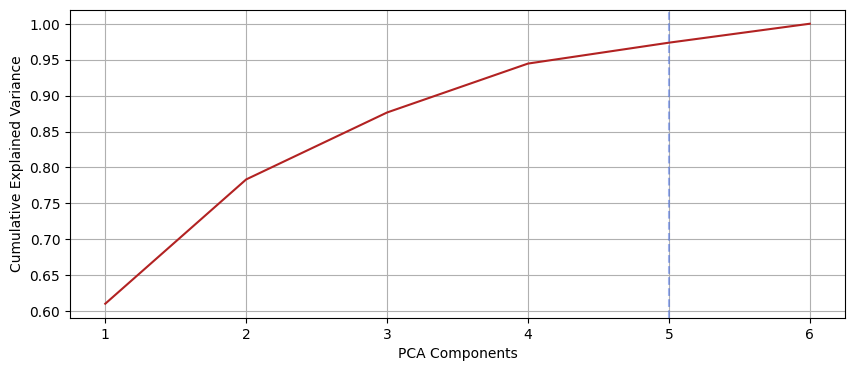

In [15]:
x = df_merged

#We are using sklearn.decomposition.PCA here
p = PCA()
y = p.fit_transform(x)

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(np.arange(1, x.shape[1]+1), np.cumsum(p.explained_variance_ratio_), color='firebrick')

#This calculates the number of PCA components required to surpass the variance threshold
comps_above_thresh = np.argwhere(np.cumsum(p.explained_variance_ratio_)>variance_threshold)[0][0]

ax.axvline(x=comps_above_thresh, color='royalblue', linestyle='--', alpha=0.5)
#ax.text(x = comps_above_thresh + 1, y = 0.5, s=f'{comps_above_thresh}th component')
ax.set_xlabel('PCA Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.grid()

print(f'We\'ll pick the first {comps_above_thresh} components that explain {variance_threshold*100}% of the variance.')

PCA Components Visualization

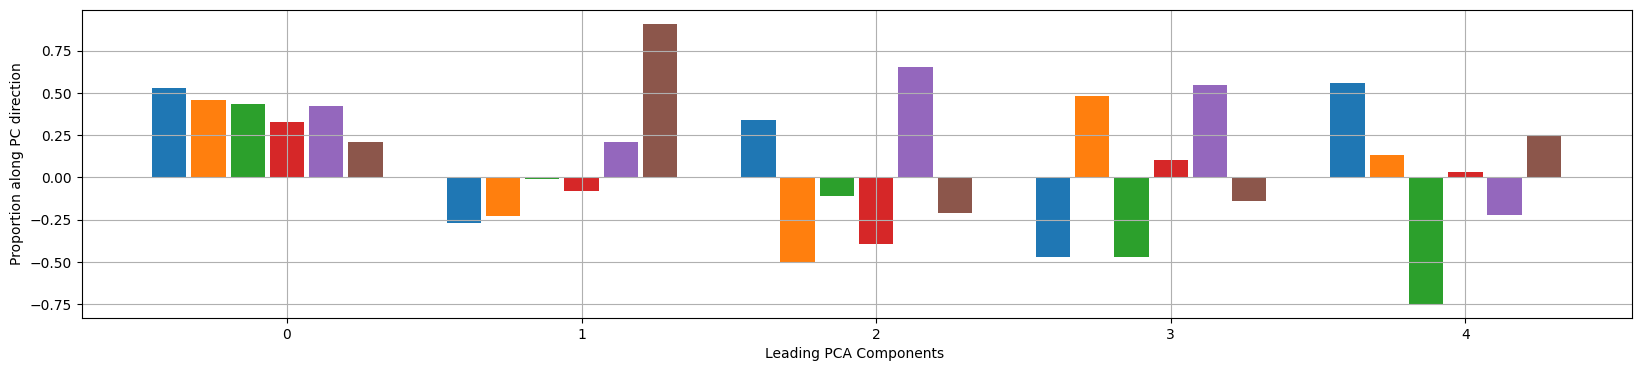

In [16]:
fig, ax = plt.subplots(figsize=(20,4))

for i in range(comps_above_thresh):
  for pi in range(x.shape[1]):
    ax.bar((i-0.4+pi*(0.8/x.shape[1])), p.components_[i, pi], width=(0.7/x.shape[1]), label=f'Angle{i}')
  ax.set_prop_cycle(None)

ax.set_xlabel('Leading PCA Components ')
ax.set_ylabel('Proportion along PC direction')
# ax.legend()
ax.grid()
plt.show()

Picking PCA Components

In [17]:
#picking PCA components above threshold
y = y[:,:comps_above_thresh]
print(y.shape)

# Re-divide the PCA embeddings into the original datasets based on the source_id column
df_concat['pca_embedding'] = list(y)
pca_embeddings = []
for dataset_id in dataset_names:
    dataset_df = df_concat[df_concat["source_id"] == dataset_id].loc[:, ['pca_embedding', 'real_timestamp']].copy()
    pca_embeddings.append(dataset_df)
    print(f"Dataset {dataset_id}: dataframe with shape {dataset_df.shape}")

print(f"Example of PCA embedding for dataset 1:\n{pca_embeddings[1].head()}\n")

(19678, 5)
Dataset Observation_hive1: dataframe with shape (4173, 2)
Dataset Observation_hive2: dataframe with shape (1987, 2)
Dataset Idle_hive2: dataframe with shape (1351, 2)
Dataset Idle_hive1: dataframe with shape (1475, 2)
Dataset Constant_hive2: dataframe with shape (419, 2)
Dataset SharpNight_hive1: dataframe with shape (1988, 2)
Dataset SharpDay_hive2: dataframe with shape (1231, 2)
Dataset SharpDay_hive1: dataframe with shape (1524, 2)
Dataset SharpNight_hive2: dataframe with shape (981, 2)
Dataset SoftNight_hive1: dataframe with shape (1540, 2)
Dataset SoftDay_hive2: dataframe with shape (1157, 2)
Dataset SoftDay_hive1: dataframe with shape (1852, 2)
Example of PCA embedding for dataset 1:
                                            pca_embedding                          real_timestamp     
datetime                                                                                              
2024-10-11 13:10:00+00:00  [0.3690867283210506, 2.085156991050014, 0.4938... 2024-10

# 3.&nbsp; Creating an mmpy project directory

Setup Folders

In [18]:
import sys
sys.path.insert(0, os.path.abspath('motionmapperpy-master'))
for module_name in list(sys.modules):
    if module_name == 'motionmapperpy' or module_name.startswith('motionmapperpy.'):
        del sys.modules[module_name]
import motionmapperpy as mmpy
print('Using motionmapperpy from:', mmpy.__file__)
%matplotlib inline

# This creates a project directory structure which will be used to store all motionmappery pipeline
# related data in one place.

mmpy.createProjectDirectory(projectPath)
for dataset_id, dataset_df in enumerate(pca_embeddings):
    # Save the PCA embeddings for each dataset into a .mat file
    dataset_name = dataset_names[dataset_id]
    dataset_real_timestamps = pd.to_datetime(dataset_df.loc[:, 'real_timestamp'], utc=True).view('int64').to_numpy()
    dataset_shifted_timestamps = pd.to_datetime(dataset_df.index, utc=True).view('int64')
    dataset_pca_embeddings = dataset_df.loc[:, 'pca_embedding']
    # Convert the array elements to np arrays too
    dataset_pca_embeddings = np.array([np.array(row) for row in dataset_pca_embeddings])
    dataset_projection_metadata = {
        'projections': dataset_pca_embeddings,
        'real_timestamps': dataset_real_timestamps,
        'shifted_timestamps': dataset_shifted_timestamps,
    }
    print(f"Saving {len(dataset_pca_embeddings)} points for dataset {dataset_name} to {projectPath}/Projections/{dataset_name}_pcaModes.mat")

    hdf5storage.savemat(f'{projectPath}/Projections/{dataset_name}_pcaModes.mat', dataset_projection_metadata)

Using motionmapperpy from: /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/motionmapperpy-master/motionmapperpy/__init__.py
Creating : /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindScaledVisualActivityWholeHiveNewTiming/
Creating : /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindScaledVisualActivityWholeHiveNewTiming//Projections
Creating : /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindScaledVisualActivityWholeHiveNewTiming//TSNE_Projections
Creating : /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindScaledVisualActivityWholeHiveNewTiming//TSNE
Creating : /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindScaledVis

Setup Parameters
- Important parameters for Wavelet Transform are : minF, maxF, samplingFreq, numPeriods
- Important parameters for UMAP are : n_neighbors, min_dist

In [19]:
#% Load the default parameters.
parameters = mmpy.setRunParameters()

# %%%%%%% PARAMETERS TO CHANGE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# These need to be revised everytime you are working with a new dataset. #

parameters.projectPath = projectPath #% Full path to the project directory.


parameters.method = 'UMAP' #% We can choose between 'TSNE' or 'UMAP'

parameters.minF = 1/(24*3600)       #% Minimum frequency for Morlet Wavelet Transform
                                    # Here 1/24h

parameters.maxF = 1/(1800)          #% Maximum frequency for Morlet Wavelet Transform,
                                    #% usually equal to the Nyquist frequency for your
                                    #% measurements. Here 1/30min.

parameters.samplingFreq = 1/(600)   #% Sampling frequency (or FPS) of data.

parameters.numPeriods = 200      #% No. of dyadically spaced frequencies to
                                 #% calculate between minF and maxF.

parameters.pcaModes = comps_above_thresh #% Number of low-d features.

parameters.numProcessors = -1     #% No. of processor to use when parallel
                                 #% processing for wavelet calculation (if not using GPU)
                                 #% and for re-embedding. -1 to use all cores
                                 #% available.

parameters.useGPU = -1           #% GPU to use for wavelet calculation,
                                 #% set to -1 if GPU not present.

parameters.training_numPoints = 415    #% Number of points in mini-trainings, per dataset.

parameters.waveletEdgeTrimSamples = 24 # Number of samples to trim from the edges of the wavelet transform (4h at 10min resolution)


# %%%%% NO NEED TO CHANGE THESE UNLESS MEMORY ERRORS OCCUR %%%%%%%%%%

parameters.trainingSetSize = 3100  #% Total number of training set points to find.
                                 #% Increase or decrease based on
                                 #% available RAM. For reference, 36k is a
                                 #% good number with 64GB RAM.

parameters.embedding_batchSize = 50000  #% Lower this if you get a memory error when
                                        #% re-embedding points on a learned map.

# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [20]:
# %%%%%%% tSNE parameters %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

#% can be 'barnes_hut' or 'exact'. We'll use barnes_hut for this tutorial for speed.
parameters.tSNE_method = 'barnes_hut'

# %2^H (H is the transition entropy)
parameters.perplexity = 32

# %number of neigbors to use when re-embedding
parameters.maxNeighbors = 200

# %local neighborhood definition in training set creation
parameters.kdNeighbors = 5

# %t-SNE training set perplexity
parameters.training_perplexity = 20


# %%%%%%%% UMAP Parameters %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# Size of local neighborhood for UMAP.
parameters.n_neighbors = 50

# Negative sample rate while training.
parameters.train_negative_sample_rate = 5

# Negative sample rate while embedding new data.
parameters.embed_negative_sample_rate = 1

# Minimum distance between neighbors.
parameters.min_dist = 0.1

In [21]:
# Store this dict to the project directory for future reference as pkl
pickle.dump(parameters, open(f"{projectPath}/parameters.pkl", "wb"))

# Also store the notebook's own data-pipeline configuration alongside it, so a project can be
# revisited later and still tell which experiments/settings fed it.
pipeline_config = {
    "used_exp_list": used_exp_list,
    "required_keys": sorted(required_keys),
    "resolution": resolution,
    "only_ambT": True,  # always True for Metabolism downloads
    "include_temperature": include_temperature,
    "include_activity": True,
    "bee_scaled_activity": use_bee_scaled_activity,
    "bee_scale": bee_scale,
    "whole_hive": whole_hive,
    "WideNormalisation": WideNormalisation,
    "variance_threshold": variance_threshold,
    "min_regions": min_regions,
}
pickle.dump(pipeline_config, open(f"{projectPath}/pipeline_config.pkl", "wb"))

parameters

{'numProcessors': -1,
 'numPeriods': 200,
 'omega0': 5,
 'samplingFreq': 0.0016666666666666668,
 'minF': 1.1574074074074073e-05,
 'maxF': 0.0005555555555555556,
 'tSNE_method': 'barnes_hut',
 'perplexity': 32,
 'embedding_batchSize': 50000,
 'maxOptimIter': 100,
 'trainingSetSize': 3100,
 'maxNeighbors': 200,
 'kdNeighbors': 5,
 'training_perplexity': 20,
 'training_numPoints': 415,
 'minTemplateLength': 1,
 'waveletDecomp': True,
 'waveletGapThresholdMultiplier': 1.5,
 'waveletEdgeTrimSamples': 24,
 'useGPU': -1,
 'n_neighbors': 50,
 'train_negative_sample_rate': 5,
 'embed_negative_sample_rate': 1,
 'min_dist': 0.1,
 'umap_output_dims': 2,
 'n_training_epochs': 1000,
 'rescale_max': 100,
 'method': 'UMAP',
 'projectPath': '/Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindScaledVisualActivityWholeHiveNewTiming/',
 'pcaModes': 5}

# 4.&nbsp; Creating a training set and embedding it using UMAP

In [22]:
t1 = time.time()

# Run subsampled embedding pipeline (will read projection files from disk)
mmpy.subsampled_tsne_from_projections(parameters)

print(f'Done in {time.time()-t1} seconds.')

Finding Training Set
Finding training set contributions from data set 1/12 : 
/Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindScaledVisualActivityWholeHiveNewTiming//Projections/SoftDay_hive2_pcaModes.mat
	 Loading Projections
	 Calculating Wavelets
Wavelet chunk report: kept 863/1157 samples (74.59%). Retained chunks: 1, skipped chunks: 9, skipped samples: 246.
	 Wavelet coverage: 863/1157 samples (74.59%) retained after chunk trimming.
DEBUG wavelet: N=1157, kept=863, data_rows=863, firstFrame=327, skipLength=2, numPoints=415, end_pos=863, selected=268, kept_selected=268
DEBUG pos_positions range: min=327, max=861


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Finding Templates.
Finding training set contributions from data set 2/12 : 
/Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindScaledVisualActivityWholeHiveNewTiming//Projections/Idle_hive2_pcaModes.mat
	 Loading Projections
	 Calculating Wavelets
	 Wavelet coverage: 1351/1351 samples (100.00%) retained after chunk trimming.
DEBUG wavelet: N=1351, kept=1351, data_rows=1351, firstFrame=106, skipLength=3, numPoints=415, end_pos=1351, selected=415, kept_selected=415
DEBUG pos_positions range: min=106, max=1348
Finding Templates.
Finding training set contributions from data set 3/12 : 
/Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindScaledVisualActivityWholeHiveNewTiming//Projections/SharpNight_hive1_pcaModes.mat
	 Loading Projections
	 Calculating Wavelets
	 Wavelet coverage: 1892/1988 samples (95.17%) retained after chunk trimming.
DEBUG wavelet: N=1988, kept=1

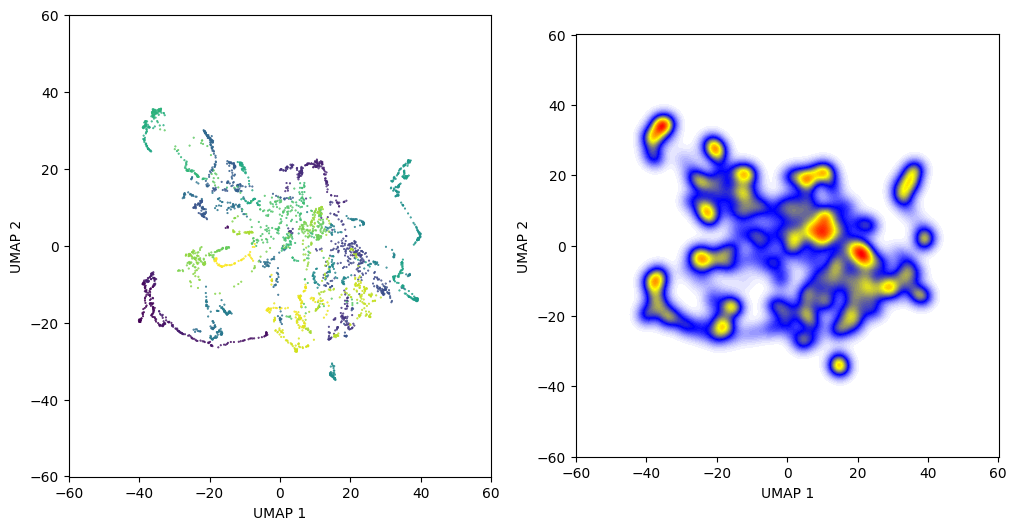

In [23]:
trainy = hdf5storage.loadmat(f'{parameters.projectPath}/{parameters.method}/training_embedding.mat')['trainingEmbedding']
m = np.abs(trainy).max()

sigma=2.0
_, xx, density = mmpy.findPointDensity(trainy, sigma, 511, [-m-20, m+20])

fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].scatter(trainy[:,0], trainy[:,1], marker='.', c=np.arange(trainy.shape[0]), s=1)
axes[0].set_xlim([-m-20, m+20])
axes[0].set_ylim([-m-20, m+20])
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].imshow(density, cmap=mmpy.gencmap(), extent=(xx[0], xx[-1], xx[0], xx[-1]), origin='lower')
fig.show()

# 5.&nbsp; Finding embeddings for all data

In [24]:
tall = time.time()

tfolder = parameters.projectPath+'/%s/'%parameters.method

# Loading training data
with h5py.File(tfolder + 'training_data.mat', 'r') as hfile:
    trainingSetData = hfile['trainingSetData'][:].T

# Loading training embedding
with h5py.File(tfolder+ 'training_embedding.mat', 'r') as hfile:
    trainingEmbedding= hfile['trainingEmbedding'][:].T

if parameters.method == 'TSNE':
    zValstr = 'zVals'
else:
    zValstr = 'uVals'

projectionFiles = glob.glob(parameters.projectPath+'/Projections/*pcaModes.mat')
for i in range(len(projectionFiles)):
    print('Finding Embeddings')
    t1 = time.time()
    print(f'{i+1}/{len(projectionFiles)} : {projectionFiles[i]}')

    # load projections and timestamp metadata for a dataset
    projection_payload = hdf5storage.loadmat(projectionFiles[i])
    projections = projection_payload['projections']
    timestamps = projection_payload.get('real_timestamps')

    # Find Embeddings
    zValues, outputStatistics = mmpy.findEmbeddings(
        projections,
        trainingSetData,
        trainingEmbedding,
        parameters,
        timestamps=timestamps,
        saveWaveletAmps=True)

    # Save embeddings
    hdf5storage.write(data = {'zValues':zValues}, path = '/', truncate_existing = True,
                    filename = projectionFiles[i][:-4]+f'_{zValstr}.mat', store_python_metadata = False,
                      matlab_compatible = True)

    # Save output statistics
    with open(projectionFiles[i][:-4] + f'_{zValstr}_outputStatistics.pkl', 'wb') as hfile:
        pickle.dump(outputStatistics, hfile)

    del zValues, projections, outputStatistics

print(f'All Embeddings Saved in {time.time()-tall} seconds!')


Finding Embeddings
1/12 : /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindScaledVisualActivityWholeHiveNewTiming//Projections/SoftDay_hive2_pcaModes.mat
Finding Wavelets
Wavelet chunk report: kept 863/1157 samples (74.59%). Retained chunks: 1, skipped chunks: 9, skipped samples: 246.
Wavelet coverage: 863/1157 samples (74.59%) retained after chunk trimming.
Finding Embeddings
	Loading UMAP Model.
	Loaded.
Embeddings found in 7.62 seconds.
Finding Embeddings
2/12 : /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindScaledVisualActivityWholeHiveNewTiming//Projections/Idle_hive2_pcaModes.mat
Finding Wavelets
Wavelet coverage: 1351/1351 samples (100.00%) retained after chunk trimming.
Finding Embeddings
	Loading UMAP Model.
	Loaded.
Embeddings found in 7.86 seconds.
Finding Embeddings
3/12 : /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethogr

Visualisation of Density Map

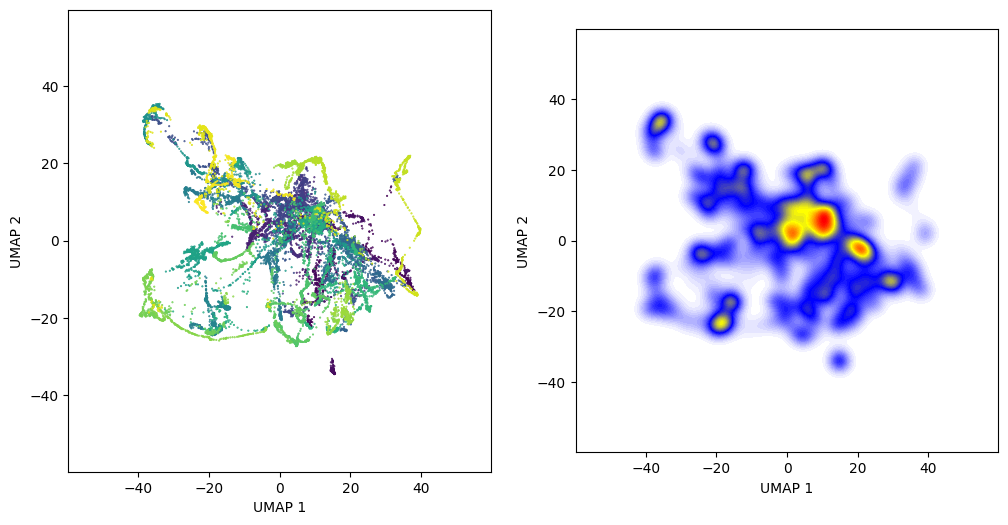

In [25]:
# load all the embeddings
ally = np.array([])
for i in glob.glob(parameters.projectPath+f'/Projections/*_{zValstr}.mat'):
  proj_ally = hdf5storage.loadmat(i)['zValues']
  ally = np.vstack([ally, proj_ally]) if ally.size else proj_ally

m = np.abs(ally).max()


fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].scatter(ally[:,0], ally[:,1], marker='.', c=np.arange(ally.shape[0]), s=1)
axes[0].set_xlim([-m-20, m+20])
axes[0].set_ylim([-m-20, m+20])
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")

sigma=2.0
_, xx, density = mmpy.findPointDensity(ally, sigma, 511, [-m-20, m+20])

axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].imshow(density, cmap=mmpy.gencmap(), extent=(xx[0], xx[-1], xx[0], xx[-1]), origin='lower')
fig.show()

# 6.&nbsp; Watershed transform on the density map

1/12 Loading embedding for SoftDay_hive2_pcaModes 0.00 seconds.
2/12 Loading embedding for Idle_hive2_pcaModes 0.01 seconds.
3/12 Loading embedding for SharpNight_hive1_pcaModes 0.01 seconds.
4/12 Loading embedding for SharpDay_hive2_pcaModes 0.01 seconds.
5/12 Loading embedding for Observation_hive2_pcaModes 0.01 seconds.
6/12 Loading embedding for SoftNight_hive1_pcaModes 0.01 seconds.
7/12 Loading embedding for Constant_hive2_pcaModes 0.01 seconds.
8/12 Loading embedding for SharpNight_hive2_pcaModes 0.01 seconds.
9/12 Loading embedding for Observation_hive1_pcaModes 0.01 seconds.
10/12 Loading embedding for SharpDay_hive1_pcaModes 0.02 seconds.
11/12 Loading embedding for Idle_hive1_pcaModes 0.02 seconds.
12/12 Loading embedding for SoftDay_hive1_pcaModes 0.02 seconds.
Starting watershed transform...
Assigning watershed regions...
	 tempsave done.
All data saved in UMAP/zVals_wShed_groups.mat.
Using /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogra

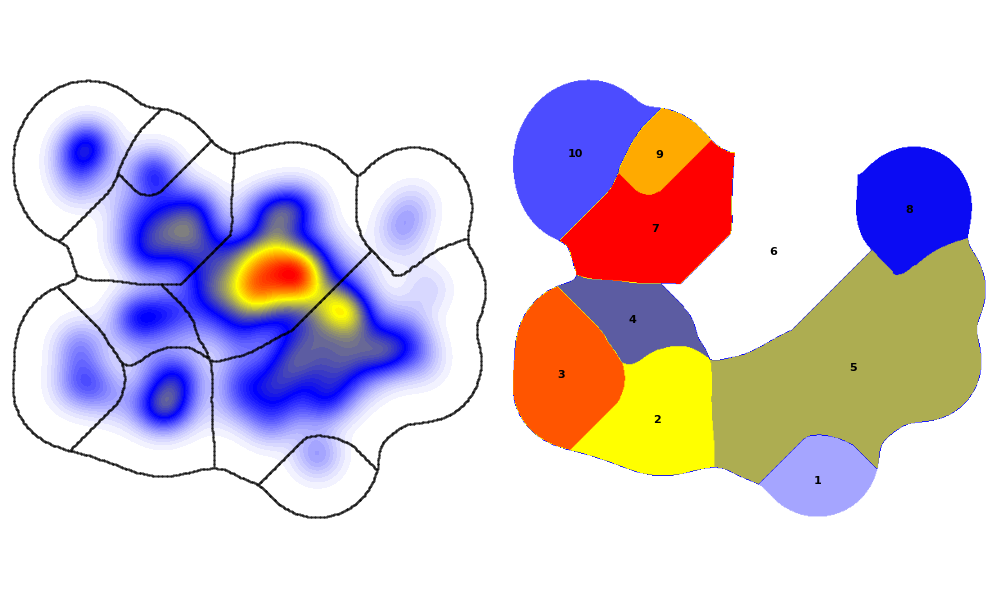

In [26]:
startsigma = 1.0 if parameters.method == 'TSNE' else 1.0
mmpy.findWatershedRegions(parameters, minimum_regions=min_regions, startsigma=startsigma, pThreshold=[0.33, 0.67], saveplot=True, endident = '*_pcaModes.mat')

# wshedTransform() names the file zWshed{numRegs}.png, where numRegs is the actual region
# count it converged to (<= min_regions, since it keeps raising sigma until the count drops
# to or below the target) -- not min_regions itself. Runs with different min_regions values
# leave multiple zWshed*.png files behind, and glob(...)[0] just grabs whichever one glob
# happens to list first, not necessarily the one from this run. Pick the file whose region
# count is the closest match at or below the current min_regions instead.
wshed_pngs = glob.glob(f'{parameters.projectPath}/{parameters.method}/zWshed*.png')
region_counts = {}
for p in wshed_pngs:
    m = re.search(r'zWshed(\d+)\.png$', os.path.basename(p))
    if m:
        region_counts[p] = int(m.group(1))

candidates = {p: n for p, n in region_counts.items() if n <= min_regions}
if not candidates:
    raise FileNotFoundError(
        f"No zWshed*.png found with region count <= min_regions ({min_regions}) in "
        f"{parameters.projectPath}/{parameters.method}/"
    )
wshed_png = max(candidates, key=candidates.get)
print(f"Using {wshed_png} ({candidates[wshed_png]} regions) for min_regions={min_regions}.")
Image(wshed_png)


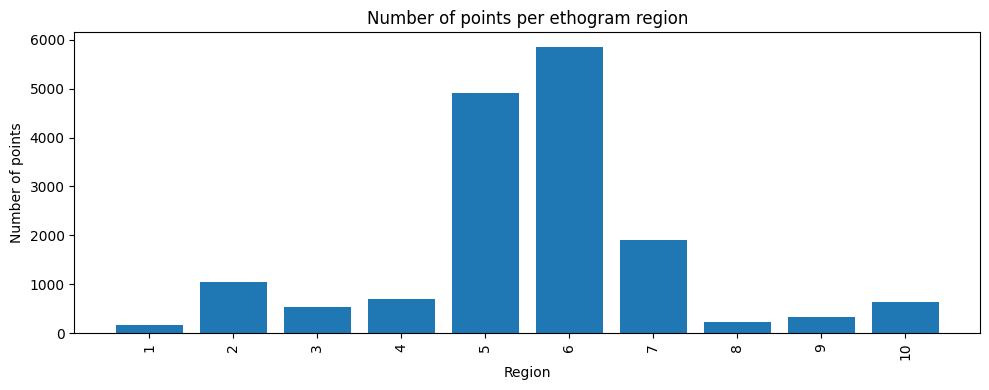

In [27]:
# wregs : 1D array containing the region label for each point (0 = background, 1..K = regions)
wshedfile = hdf5storage.loadmat(f'{parameters.projectPath}/{parameters.method}/zVals_wShed_groups.mat')
wregs = wshedfile['watershedRegions'].flatten().astype(int)
unique, counts = np.unique(wregs, return_counts=True)

# Put in DataFrame format for easier reading
df_counts = pd.DataFrame({
    "region": unique.astype(int),
    "n_points": counts.astype(int)
})

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(df_counts["region"], df_counts["n_points"])

ax.set_xlabel("Region")
ax.set_ylabel("Number of points")
ax.set_title("Number of points per ethogram region")

ax.set_xticks(df_counts["region"])
ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


In [28]:
from pathlib import Path
PROJECT_DIR = Path(projectPath)
RESULTS_DIR = PROJECT_DIR / "UMAP"
PROJECTIONS_DIR = PROJECT_DIR / "Projections"
WSHED_PATH = RESULTS_DIR / "zVals_wShed_groups.mat"

total_embeddings = 0
# retrieve the UMAP embeddings for all datapoints across all datasets
for dataset_name in dataset_names:
    dataset_mat_file = hdf5storage.loadmat(f'{PROJECTIONS_DIR}/{dataset_name}_pcaModes_uVals.mat')
    dataset_embeddings = dataset_mat_file['zValues']
    print(f"Dataset {dataset_name} embeddings shape: {dataset_embeddings.shape}")
    total_embeddings += dataset_embeddings.shape[0]

    print(f"Keys in the embeddings file: {list(dataset_mat_file.keys())}")
    outputStats = np.load(f'{PROJECTIONS_DIR}/{dataset_name}_pcaModes_uVals_outputStatistics.pkl', allow_pickle=True)
    print(f"Keys in the output statistics file: {list(outputStats.keys())}")
    kept_indices = outputStats['keptIdx']
    print(f"Kept indices shape: {kept_indices.shape}")
    print(kept_indices[:10])  # Print the first 10 kept indices
    pcaModesFile = hdf5storage.loadmat(f'{PROJECTIONS_DIR}/{dataset_name}_pcaModes.mat')
    print(f"Keys in the PCA modes file: {list(pcaModesFile.keys())}")
    timestamps = pcaModesFile['real_timestamps']
    print(f"Timestamps shape: {timestamps.shape}")
    print(timestamps[:10])  # Print the first 10 timestamps

wshedfile = hdf5storage.loadmat(str(WSHED_PATH))
print(f"Watershed file keys: {list(wshedfile.keys())}")
zvalues = wshedfile['zValues']
print(f"zValues shape: {zvalues.shape}")
print(f"In total, we got {total_embeddings} embeddings across all datasets, and the watershed file has {zvalues.shape[0]} embeddings.")

Dataset Observation_hive1 embeddings shape: (3141, 2)
Keys in the embeddings file: ['zValues']
Keys in the output statistics file: ['training_mean', 'training_scale', 'keptIdx', 'waveletCoverage', 'waveletAmplitudes', 'waveletFrequencies']
Kept indices shape: (3141,)
[27 28 29 30 31 32 33 34 35 36]
Keys in the PCA modes file: ['projections', 'real_timestamps', 'shifted_timestamps']
Timestamps shape: (4173,)
[1726239600000000000 1726240200000000000 1726240800000000000
 1726260000000000000 1726260600000000000 1726261200000000000
 1726261800000000000 1726262400000000000 1726263000000000000
 1726263600000000000]
Dataset Observation_hive2 embeddings shape: (1696, 2)
Keys in the embeddings file: ['zValues']
Keys in the output statistics file: ['training_mean', 'training_scale', 'keptIdx', 'waveletCoverage', 'waveletAmplitudes', 'waveletFrequencies']
Kept indices shape: (1696,)
[27 28 29 30 31 32 33 34 35 36]
Keys in the PCA modes file: ['projections', 'real_timestamps', 'shifted_timestamps']

# 7.&nbsp; Ethogram Interpretation Tools

## Region Timeline


In [29]:
df_nat = []

for key, df in exps_dfs_dropna.items():

    df = df.copy()

    # 1) Save the real timestamp
    df["real_timestamp"] = df.index

    # 2) add a source id column
    df["source_id"] = _source_id(key)

    df_nat.append(df)

# 3) concatenate all dataframes into one
df_nat = pd.concat(df_nat, axis=0)
df_nat = df_nat.sort_index()

print(df_nat[["real_timestamp", "source_id"]].tail())

                                real_timestamp        source_id   
datetime                                                          
2025-01-19 15:20:00+00:00 2025-01-19 15:20:00+00:00  SoftDay_hive1
2025-01-19 15:30:00+00:00 2025-01-19 15:30:00+00:00  SoftDay_hive1
2025-01-19 15:40:00+00:00 2025-01-19 15:40:00+00:00  SoftDay_hive1
2025-01-19 15:50:00+00:00 2025-01-19 15:50:00+00:00  SoftDay_hive1
2025-01-19 16:00:00+00:00 2025-01-19 16:00:00+00:00  SoftDay_hive1


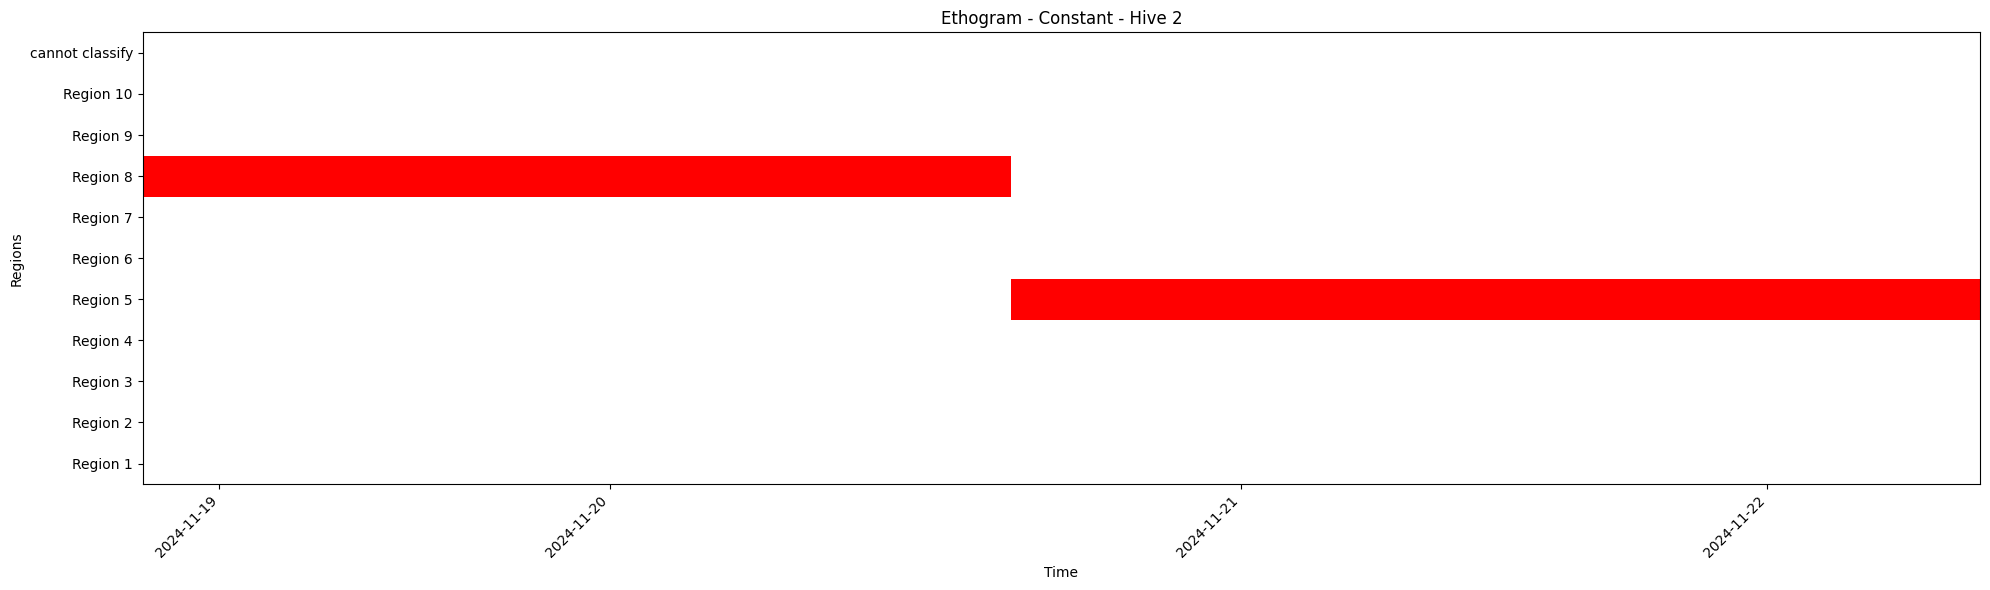

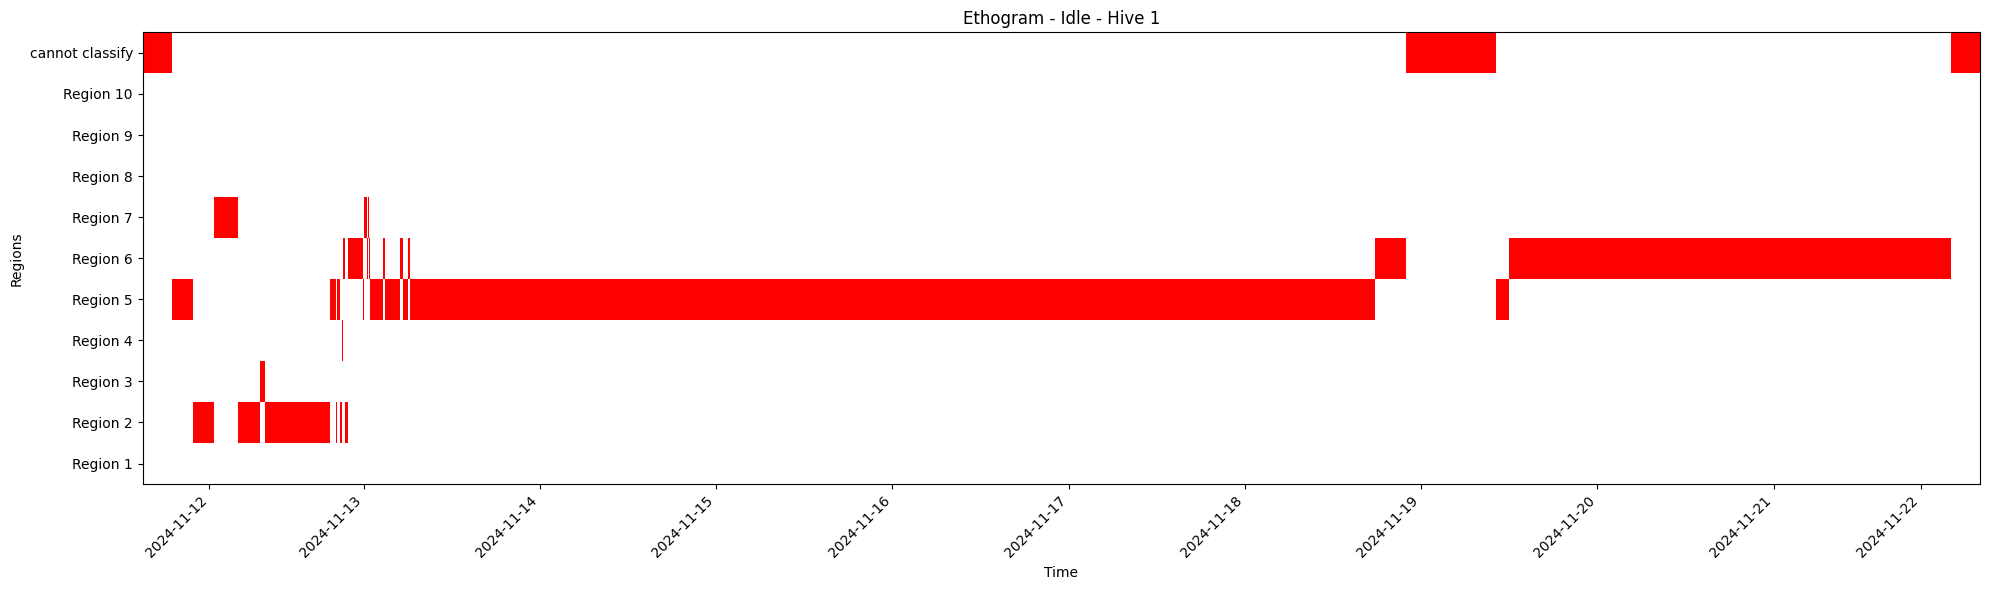

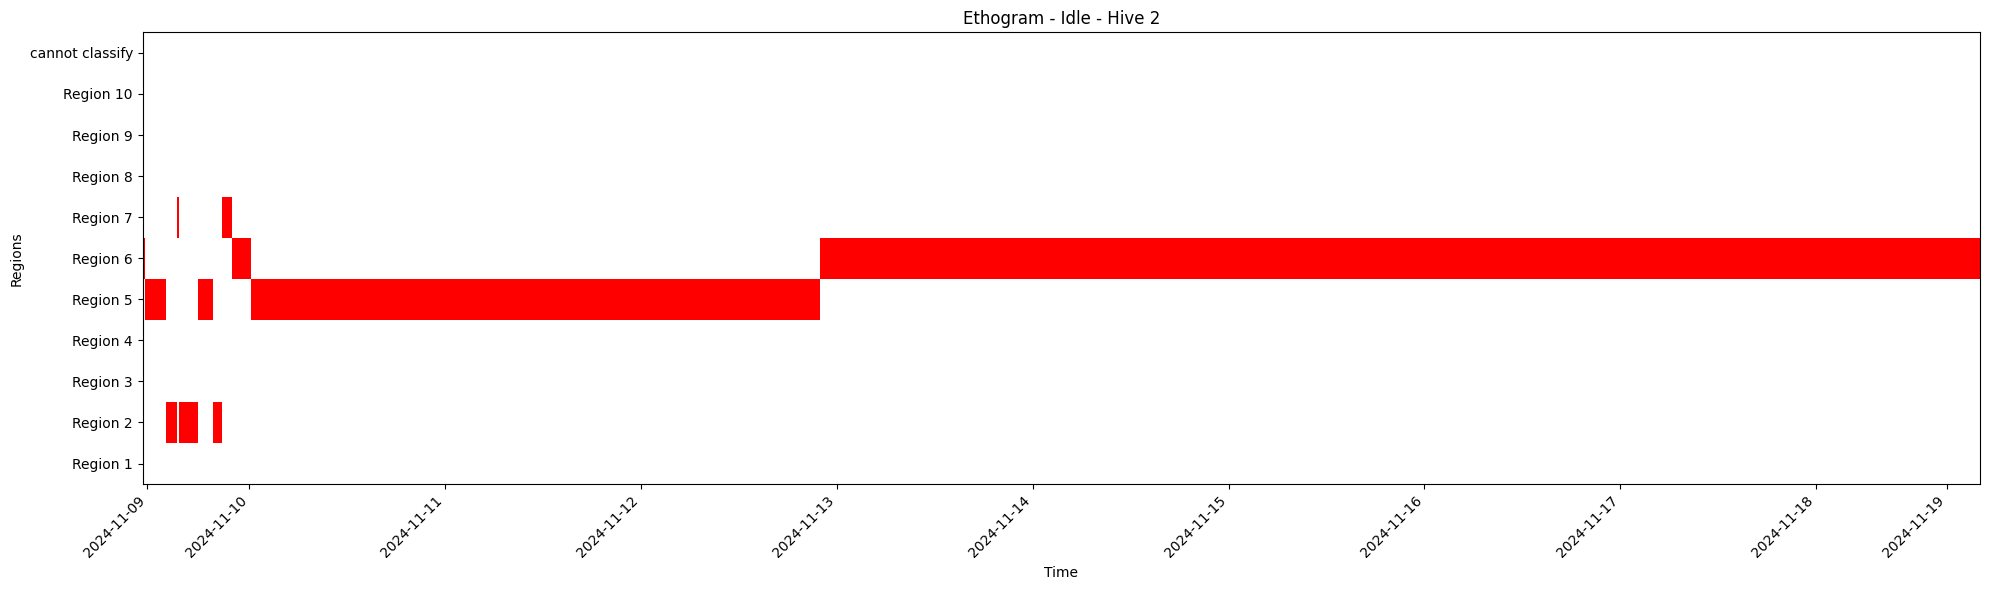

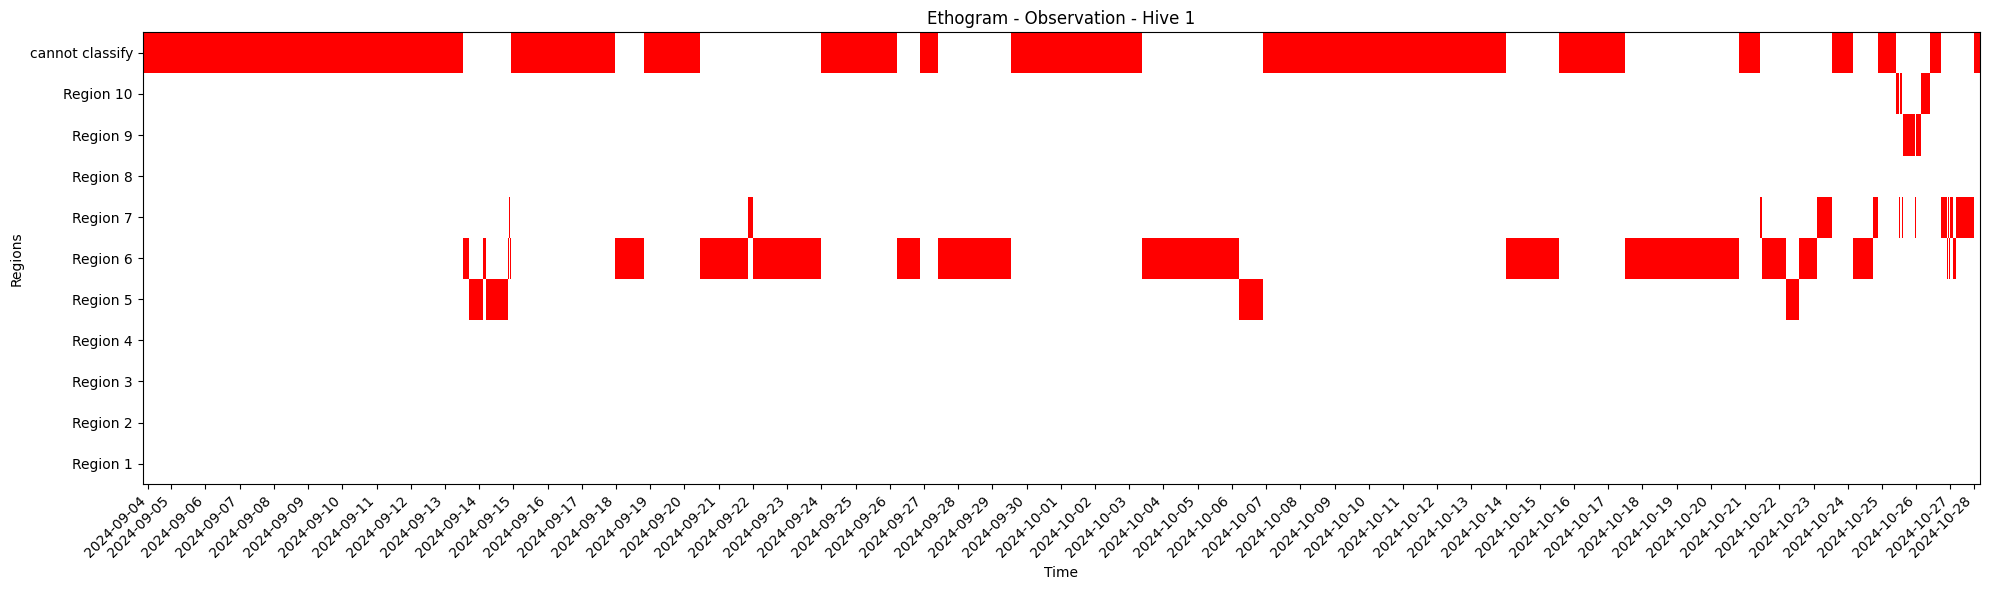

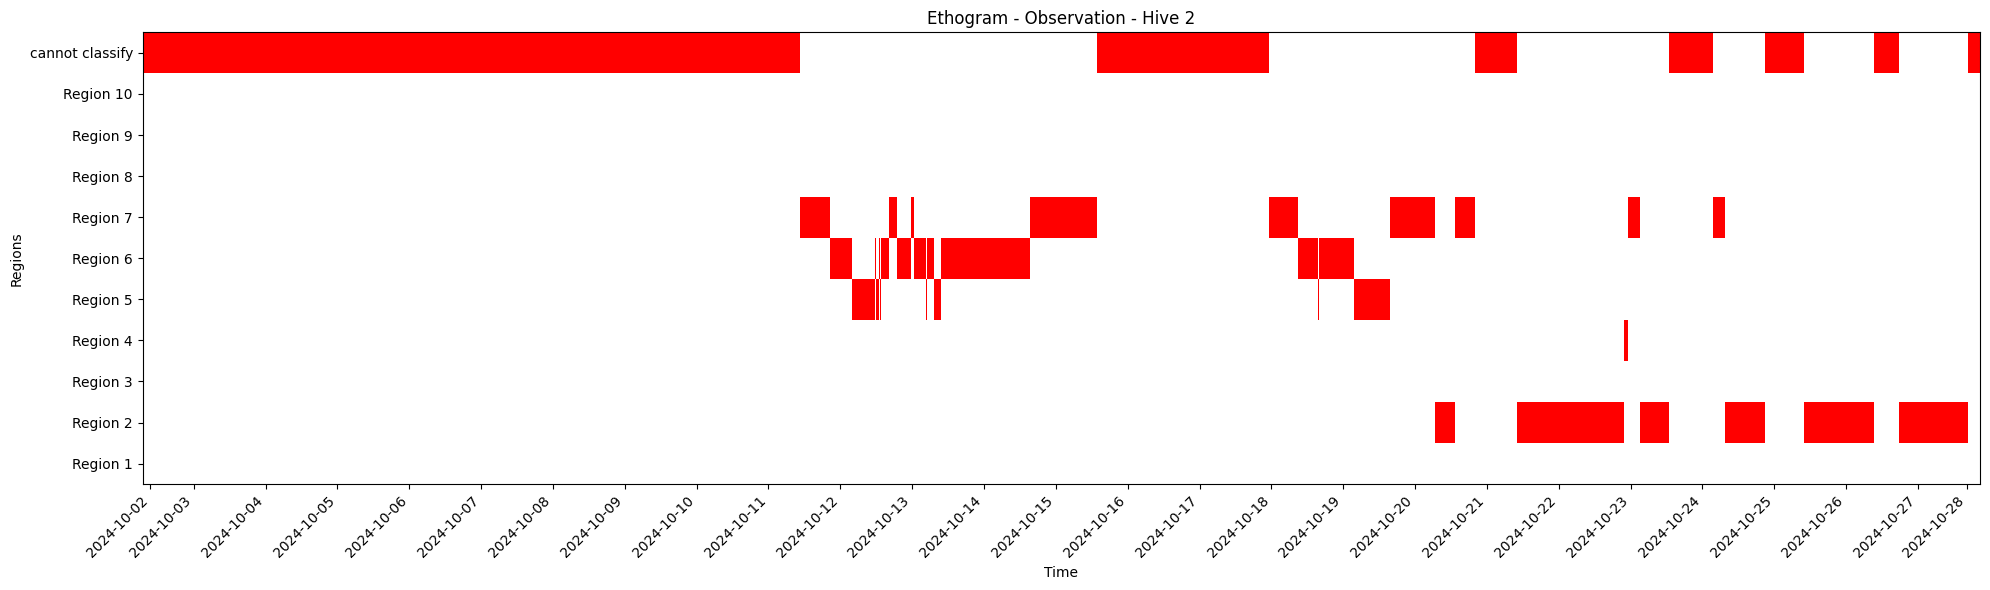

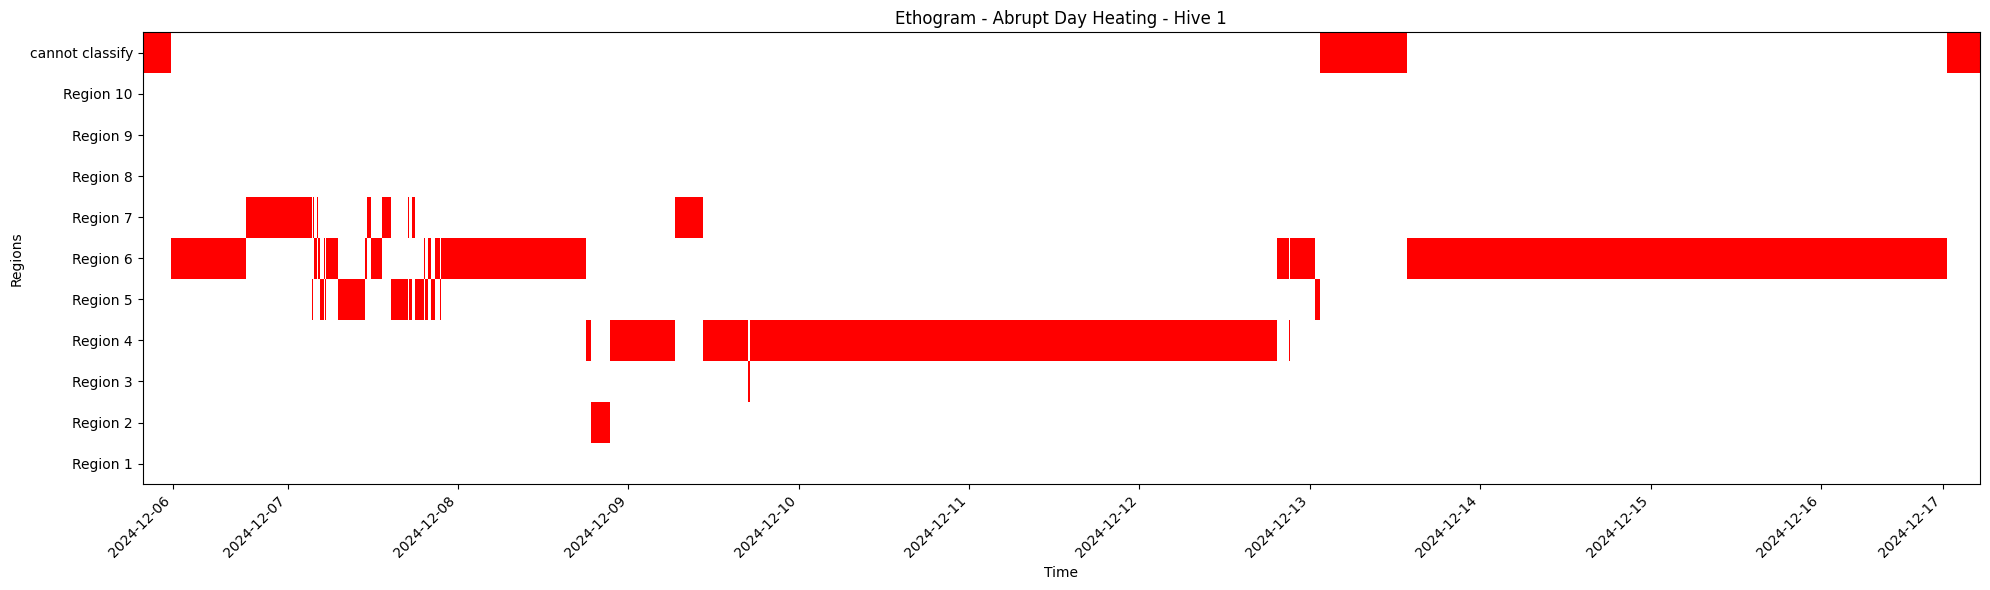

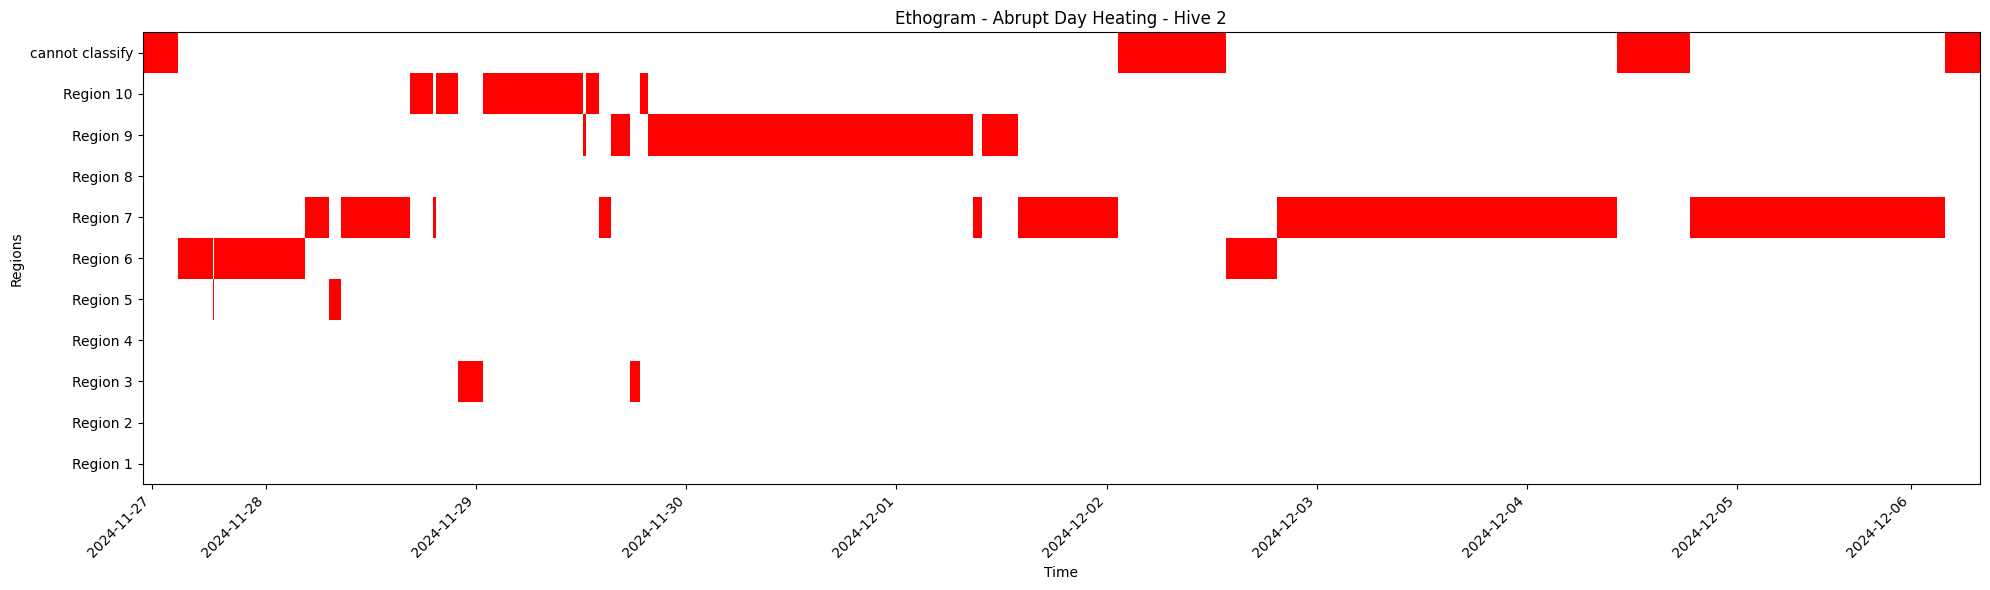

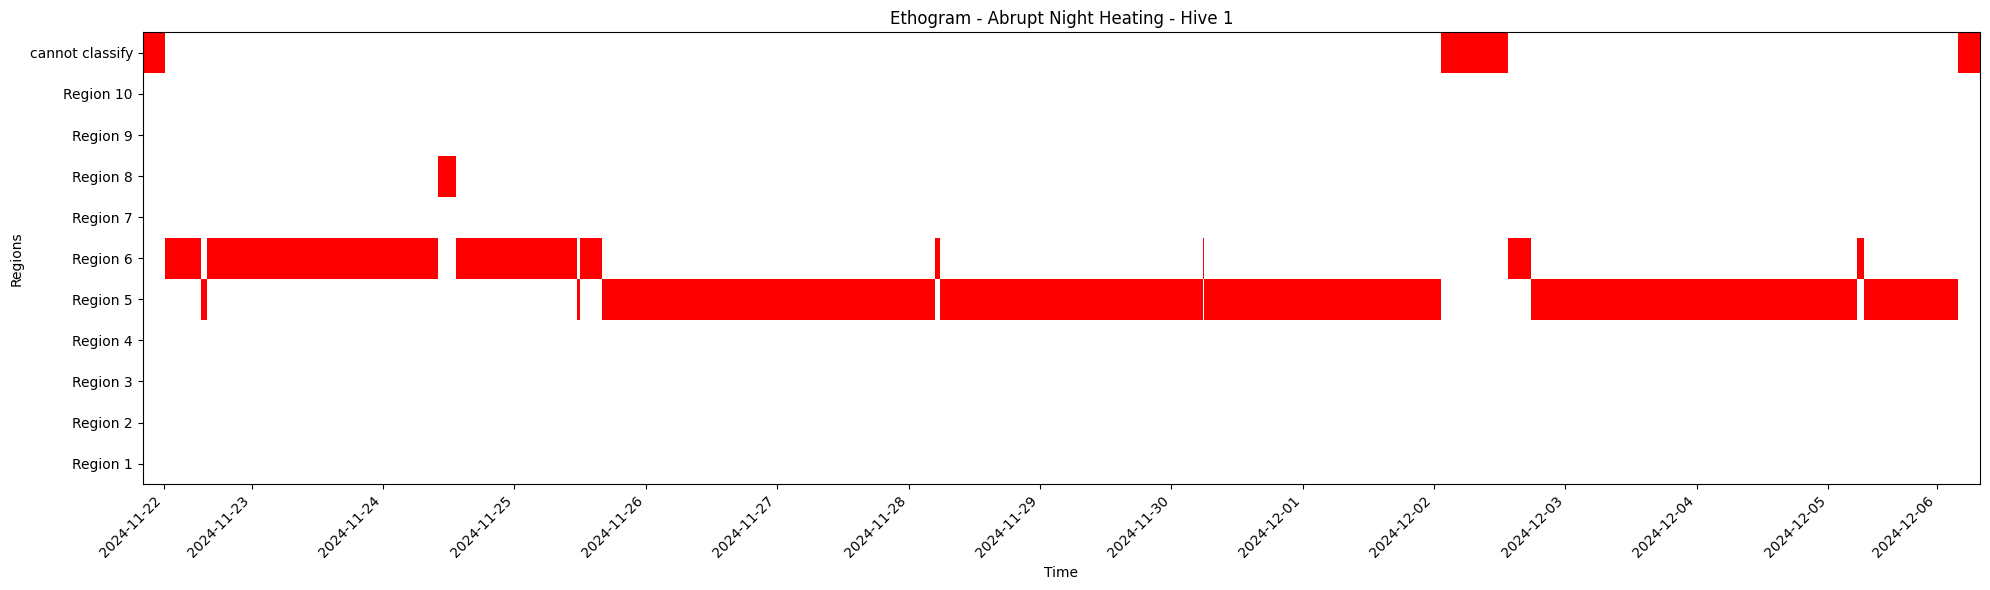

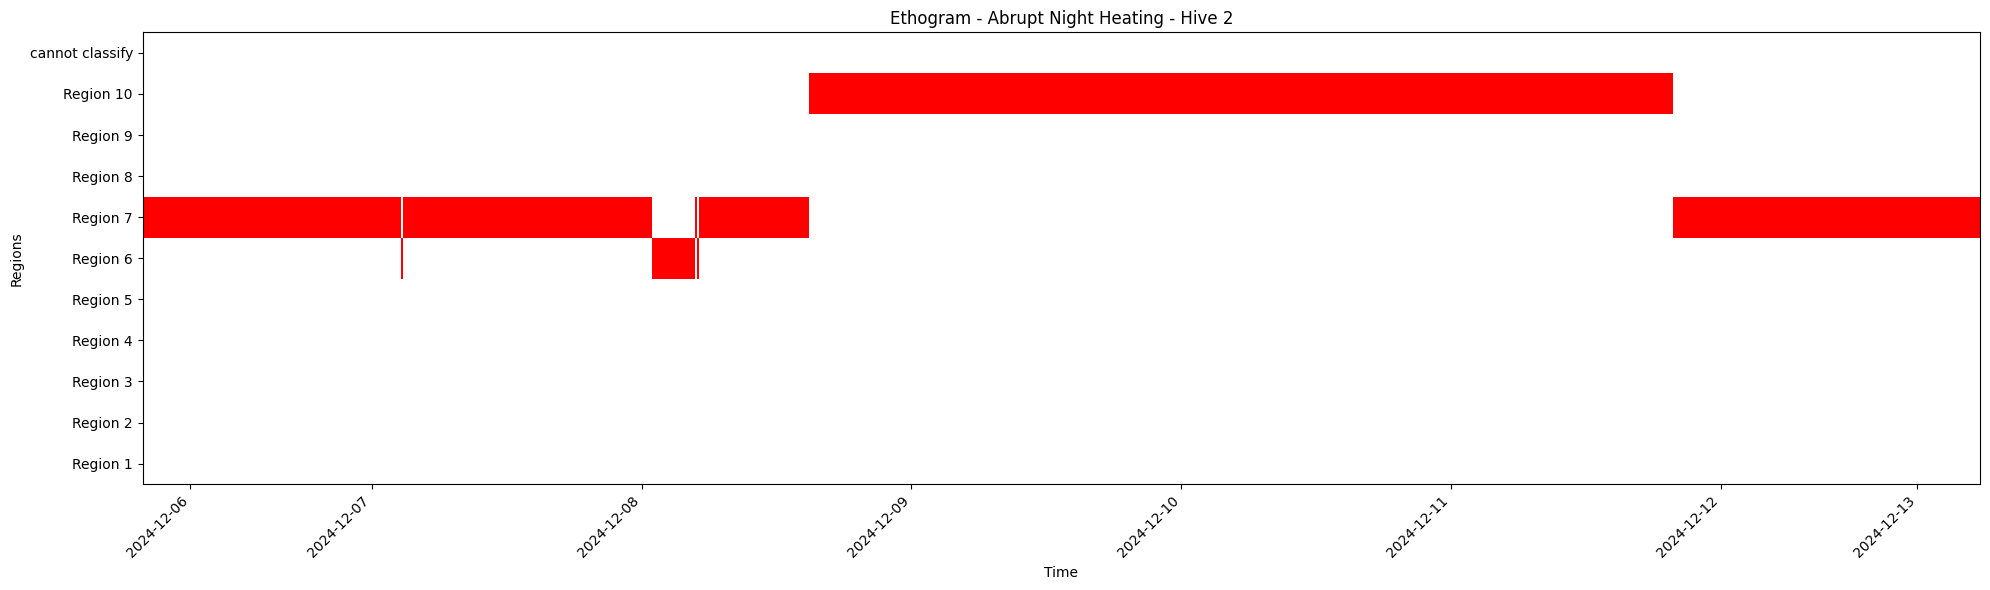

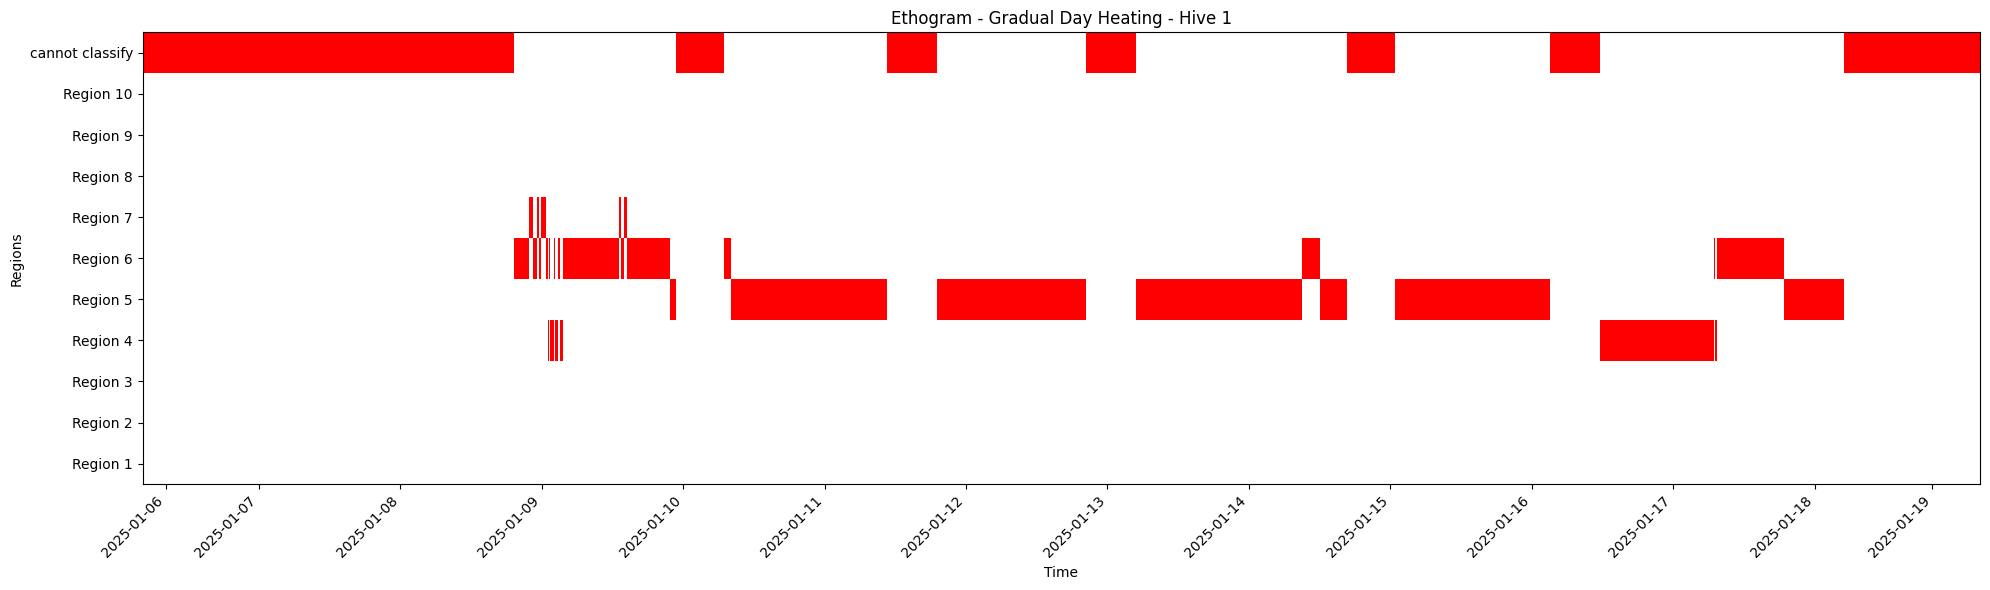

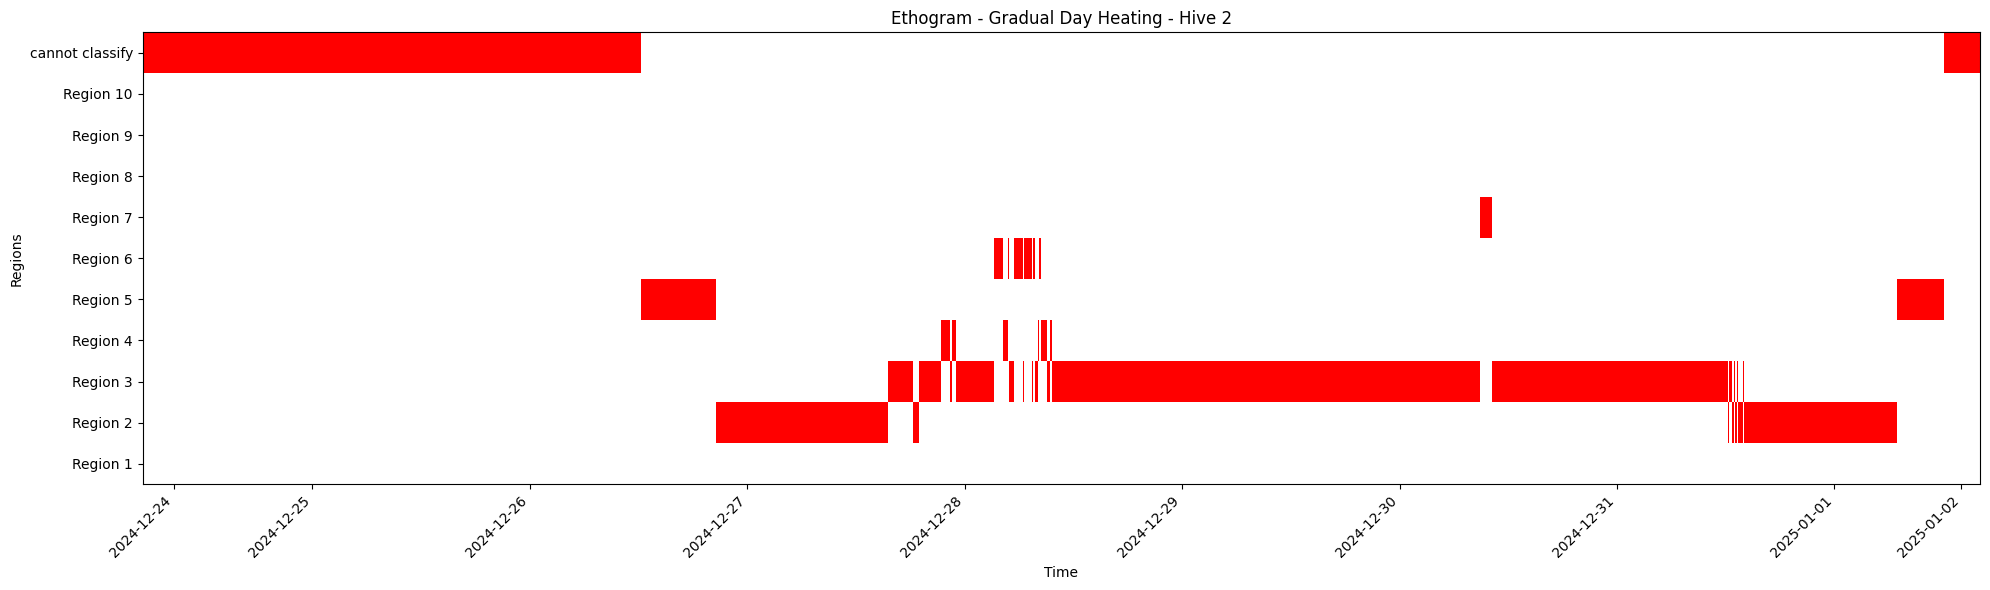

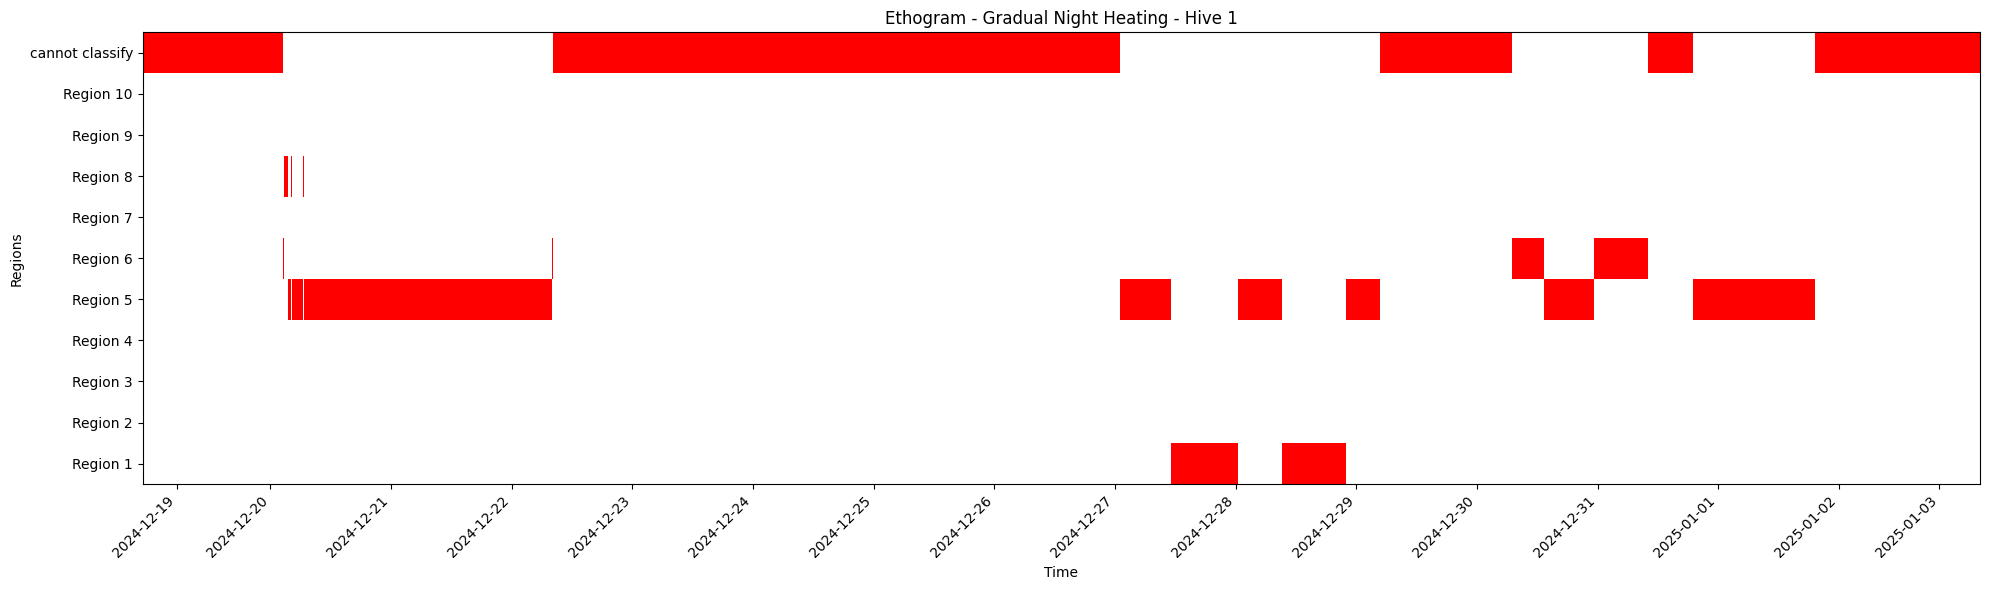

In [30]:
# --- Load kept indices from the embedding run, if available ---
# Load region assignments for all datasets from the watershed file. mmpy.findWatershedRegions
# concatenates each dataset's embeddings in whatever order glob.glob() returns them (filesystem-
# dependent -- NOT alphabetical, and NOT full_dts's insertion order), but it records the *true*
# per-dataset order and lengths as zValNames/zValLens inside the wshed file itself. Relying on a
# separately-sorted file listing (then zipping positionally against full_dts) silently misaligned
# every dataset once files stopped being named "dataset_0", "dataset_1", ... numerically.
wshedfile = hdf5storage.loadmat(f'{parameters.projectPath}/{parameters.method}/zVals_wShed_groups.mat')
wregs = wshedfile['watershedRegions'].flatten().astype(float)
zval_names = [str(np.asarray(n).ravel()[0]) for n in wshedfile['zValNames'].flatten()]
zval_lens = wshedfile['zValLens'].flatten().astype(int)
zval_offsets = np.cumsum([0] + zval_lens[:-1].tolist())

# Map each dataset's source_id (the same string used to name its pcaModes.mat file) to its
# (offset, length) block within wregs/zValues.
source_id_blocks = {}
for name, length, offset in zip(zval_names, zval_lens, zval_offsets):
    stem = name[:-len('_pcaModes')] if name.endswith('_pcaModes') else name
    source_id_blocks[stem] = (offset, length)

# Total number of watershed regions across the whole (all-datasets) map, so every
# dataset's ethogram uses the same fixed row count -- regions a given dataset never
# visits still get an (empty) row instead of being dropped from the y-axis entirely.
finite_wregs = wregs[np.isfinite(wregs) & (wregs > 0)]
total_nreg = int(finite_wregs.max()) if finite_wregs.size else 0

for key, full_dts_s in full_dts.items():
    source_id = _source_id(key)
    stats_file = f'{parameters.projectPath}/Projections/{source_id}_pcaModes_uVals_outputStatistics.pkl'
    pca_file = f'{parameters.projectPath}/Projections/{source_id}_pcaModes.mat'

    with open(stats_file, 'rb') as hfile:
        outputStatistics = pickle.load(hfile)

    pca_data = hdf5storage.loadmat(pca_file)

    keptIdx = np.asarray(outputStatistics.keptIdx).astype(int).ravel()
    real_ts = pd.to_datetime(pca_data['real_timestamps'], utc=True)
    real_ts = real_ts[keptIdx]  # Filter real timestamps to only those that were kept

    offset, length = source_id_blocks[source_id]
    assert length == len(keptIdx), (
        f"keptIdx length ({len(keptIdx)}) doesn't match the watershed block length ({length}) "
        f"for {source_id}; the wshed file may be stale relative to the Projections folder."
    )
    region_classification = wregs[offset:offset + length]  # As wregs is ordered by dataset

    full_dts_s = pd.to_datetime(full_dts_s)

    regions_lin = []
    for t in full_dts_s:
        if t in real_ts:
            idx = np.where(real_ts == t)[0][0]
            regions_lin.append(region_classification[idx])
            df_nat.loc[(df_nat["real_timestamp"] == t) & (df_nat["source_id"] == source_id), "region"] = region_classification[idx]
        else:
            regions_lin.append(np.nan)
            df_nat.loc[(df_nat["real_timestamp"] == t) & (df_nat["source_id"] == source_id), "region"] = np.nan

    # Build ethogram from regions_lin
    w_arr = np.asarray(regions_lin)
    nreg = total_nreg
    E = np.zeros((nreg + 1, w_arr.size), dtype=np.uint8)
    for j, v in enumerate(w_arr):
        if not np.isfinite(v) or v <= 0:
            E[-1, j] = 1
        else:
            rid = int(round(v))
            if 1 <= rid <= nreg:
                E[rid - 1, j] = 1
            else:
                E[-1, j] = 1

    # Build day boundaries from the shared linear timestamps (even spacing)
    dates = full_dts_s.date
    change = np.flatnonzero(np.diff(dates.astype('datetime64[D]'))) + 1
    boundaries = list(change) + [len(full_dts_s)]
    dnames, counts, start = [], [], 0
    for b in boundaries:
        dnames.append(str(pd.to_datetime(dates[start]).date()))
        counts.append(b - start)
        start = b
    bounds = np.cumsum(counts).tolist()
    # Build & plot using the shared full_dts timeline
    plot_ethogram(E, nreg, dnames, bounds, counts, title=f"Ethogram - {_pretty_label(key)}", timestamps=full_dts_s)

## Plot 100 points around barycentre

In [31]:
# Remove all rows from df_nat where the region is NaN
df_nat = df_nat.dropna(subset=["region"])
# Verify alignment
assert len(df_nat) == len(wregs), f"df_nat et wregs doivent avoir la même longueur. df_nat: {len(df_nat)}, wregs: {len(wregs)}"

# Add UMAP coords
rounded_ally = [[round(x,2) for x in row] for row in ally]
df_nat["UMAP"] = rounded_ally

print(df_nat.tail())
print(df_nat.shape)

                           co2_UL  co2_UR  co2_LL  co2_LR  rel_humid  activity       real_timestamp        source_id     region       UMAP      
datetime                                                                                                                                        
2025-01-18 16:20:00+00:00  2051.0   568.0  1407.0   598.0  40.984555  0.005380 2025-01-18 16:20:00+00:00  SoftDay_hive1    5.0   [-21.56, 10.23]
2025-01-18 16:30:00+00:00  1717.0   570.0  1162.0   569.0  40.574290  0.005162 2025-01-18 16:30:00+00:00  SoftDay_hive1    5.0   [-21.98, 10.24]
2025-01-18 16:40:00+00:00  2429.0   613.0  1699.0   620.0  40.952398  0.005229 2025-01-18 16:40:00+00:00  SoftDay_hive1    5.0     [-21.61, 9.8]
2025-01-18 16:50:00+00:00  2222.0   581.0  1858.0   595.0  40.360280  0.005293 2025-01-18 16:50:00+00:00  SoftDay_hive1    5.0   [-21.59, 10.06]
2025-01-18 17:00:00+00:00  1314.0   597.0   987.0   557.0  40.465240  0.005272 2025-01-18 17:00:00+00:00  SoftDay_hive1    5.0    

Compute Barycenters

In [32]:
rounded_ally = np.round(ally, decimals=2)
assert len(rounded_ally) == len(wregs)

region_ids = np.unique(wregs)

barycenters = {}  # dict: region_id -> (x_mean, y_mean)

for rid in region_ids:
    if rid == 0:
        # Ignore region 0 if it is the backgound
        continue
    
    mask = (wregs == rid)
    if not np.any(mask):
        continue 

    pts = rounded_ally[mask]      # shape (n_points_region, 2)
    center = pts.mean(axis=0)     # shape (2,)

    barycenters[int(rid)] = (float(center[0]), float(center[1]))

print(barycenters)


{1: (-19.873716354370117, -14.482690811157227), 2: (1.4972474575042725, -3.3256685733795166), 3: (17.534698486328125, -11.859703063964844), 4: (-29.210805892944336, -9.654264450073242), 5: (-5.33249568939209, 8.501974105834961), 6: (6.511741638183594, -3.891386032104492), 7: (2.1098809242248535, 0.3323371410369873), 8: (-9.488116264343262, 15.133496284484863), 9: (12.548768043518066, -2.831681251525879), 10: (-0.4129422903060913, 2.2310471534729004)}


Compute the 100 nearest points to the barycenters

In [33]:
closest_per_region = {}  # dict : region_id -> DataFrame of the 100 nearest points

for rid, center in barycenters.items():
    cx, cy = center

    # subset of the region
    sub = df_nat[df_nat["region"] == rid].copy()
    if sub.empty:
        continue

    # distance calculation function
    def dist_to_center(umap_xy):
        x, y = umap_xy
        return np.sqrt((x - cx)**2 + (y - cy)**2)

    sub["dist_to_center"] = sub["UMAP"].apply(dist_to_center)

    # Take the closest 100 points
    closest_per_region[rid] = sub.sort_values("dist_to_center").head(100)


Temperature Plot

In [34]:
# 1) Detection of temperature columns
sample_df = next(iter(closest_per_region.values()))
temp_cols = [c for c in sample_df.columns if c.startswith("t") and c[1:].isdigit()]
print("Temperature columns :", temp_cols)

use_tamb = False
have_temperature = True
if not temp_cols:
    if "Tamb" in sample_df.columns:
        use_tamb = True
        print("No per-sensor temperature columns ('tXX') found. Falling back to ambient temperature ('Tamb').")
    else:
        have_temperature = False
        print("No temperature columns ('tXX' or 'Tamb') found (include_temperature=False) -- skipping the temperature plot.")

region_ids = sorted(closest_per_region.keys())

if not have_temperature:
    pass

elif use_tamb:
    # --- Ambient temperature boxplot per region (single sensor, one box per region) ---
    tamb_data = []
    labels = []
    for rid in region_ids:
        df_r = closest_per_region[rid]
        if "Tamb" in df_r.columns:
            tamb_data.append(df_r["Tamb"].dropna().values)
        else:
            tamb_data.append([np.nan])
        labels.append(f"R{rid}")

    x = np.arange(len(region_ids))

    fig, ax = plt.subplots(figsize=(12, 6))
    bp_tamb = ax.boxplot(
        tamb_data,
        positions=x,
        widths=0.5,
        patch_artist=True,
        boxprops=dict(facecolor="lightsalmon", edgecolor="darkorange"),
        medianprops=dict(color="darkorange"),
        showfliers=False
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45)
    ax.set_ylabel("Ambient temperature (°C)")
    ax.set_title("Ambient temperature per Region (100 closest points to barycenter)")
    ax.legend([bp_tamb["boxes"][0]], ["Tamb"])

    plt.tight_layout()
    plt.show()

else:
    # 2) Find global min/max temperatures across all regions
    all_temp_vals = []

    for rid, df_r in closest_per_region.items():
        for c in temp_cols:
            if c in df_r.columns:
                vals = df_r[c].dropna().values
                if len(vals) > 0:
                    all_temp_vals.extend(vals)

    if not all_temp_vals:
        raise ValueError("No temperature values found in closest_per_region.")

    global_min = min(all_temp_vals)
    global_max = max(all_temp_vals)
    print("Global temp Y-limits:", global_min, global_max)

    # 3) Layout of subplots
    n_regions = len(region_ids)

    ncols = min(3, n_regions)
    nrows = int(np.ceil(n_regions / ncols))

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(5*ncols, 4*nrows),
        squeeze=False
    )

    # 4) Plot per region
    for ax, rid in zip(axes.flatten(), region_ids):
        df_r = closest_per_region[rid]

        # extraire les données de température
        data = [df_r[c].dropna().values for c in temp_cols]

        ax.boxplot(
            data,
            showfliers=False,
            widths=0.5
        )

        ax.set_title(f"Region {rid} (n={len(df_r)})")
        ax.set_xticks(range(1, len(temp_cols) + 1))
        ax.set_xticklabels(temp_cols, rotation=90, fontsize=7)
        ax.set_ylabel("Temperature")

        # Same scale for y-axis
        ax.set_ylim(global_min, global_max)

    # Delete empty axes if needed
    for i in range(len(region_ids), nrows * ncols):
        fig.delaxes(axes.flatten()[i])

    plt.tight_layout()
    plt.show()

Temperature columns : []
No temperature columns ('tXX' or 'Tamb') found (include_temperature=False) -- skipping the temperature plot.


CO2 Plot

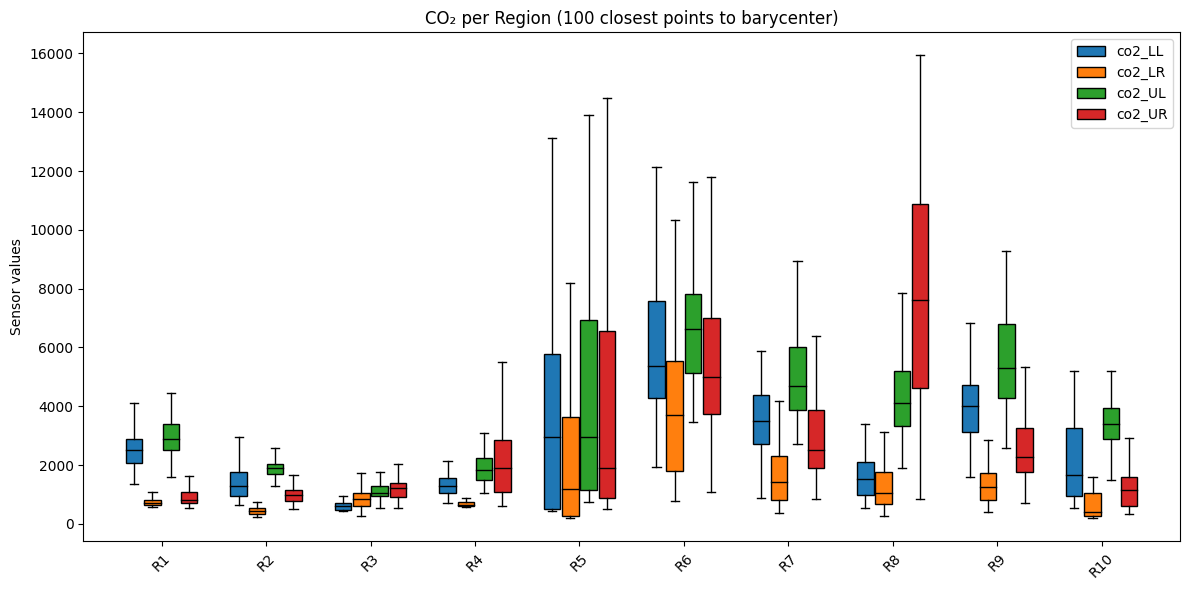

In [35]:
region_ids = sorted(closest_per_region.keys())
sample_df = next(iter(closest_per_region.values()))
co2_sensor_cols = sorted(c for c in sample_df.columns if c.startswith("co2_"))

co2_data_by_sensor = {col: [] for col in co2_sensor_cols}
labels = []

for rid in region_ids:
    df_r = closest_per_region[rid]
    for col in co2_sensor_cols:
        if col in df_r.columns:
            co2_data_by_sensor[col].append(df_r[col].dropna().values)
        else:
            co2_data_by_sensor[col].append([np.nan])
    labels.append(f"R{rid}")

x = np.arange(len(region_ids))
n_sensors = len(co2_sensor_cols)
w = 0.7 / n_sensors  # total group width 0.7, split evenly across sensors

fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.tab10.colors
boxplots = []
for i, col in enumerate(co2_sensor_cols):
    sensor_offset = (i - (n_sensors - 1) / 2.0) * w
    bp = ax.boxplot(
        co2_data_by_sensor[col],
        positions=x + sensor_offset,
        widths=w * 0.9,
        patch_artist=True,
        boxprops=dict(facecolor=colors[i % len(colors)]),
        medianprops=dict(color="black"),
        showfliers=False
    )
    boxplots.append(bp)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.set_xlim(-0.75, len(region_ids) - 0.25)
ax.set_ylabel("Sensor values")
ax.set_title("CO₂ per Region (100 closest points to barycenter)")

ax.legend([bp["boxes"][0] for bp in boxplots], co2_sensor_cols)

plt.tight_layout()
plt.show()

Humidity Plot

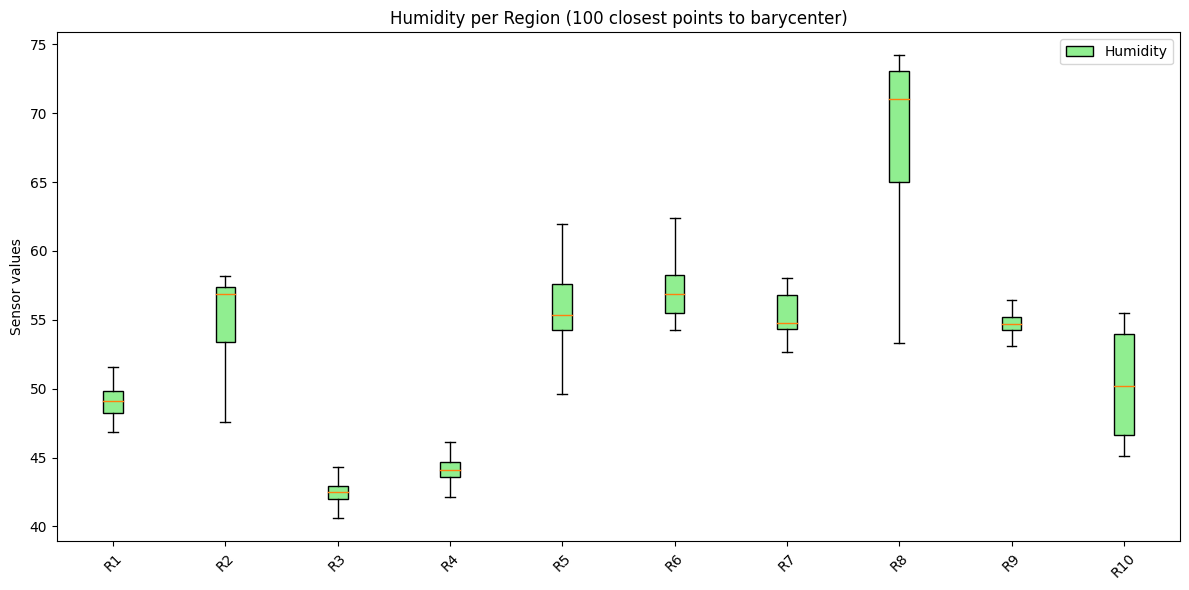

In [36]:
region_ids = sorted(closest_per_region.keys())

hum_data = []
labels = []

for rid in region_ids:
    df_r = closest_per_region[rid]

    if "rel_humid" in df_r.columns:
        hum_data.append(df_r["rel_humid"].dropna().values)
    else:
        hum_data.append([np.nan])
    
    labels.append(f"R{rid}")

x = np.arange(len(region_ids))

fig, ax = plt.subplots(figsize=(12, 6))

# boxplots Humidité
bp2 = ax.boxplot(
    hum_data,
    positions=x,
    widths=w,
    patch_artist=True,
    boxprops=dict(facecolor="lightgreen"),
    showfliers=False
)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.set_ylabel("Sensor values")
ax.set_title("Humidity per Region (100 closest points to barycenter)")

ax.legend([bp2["boxes"][0]], ["Humidity"])

plt.tight_layout()
plt.show()

Activity plots

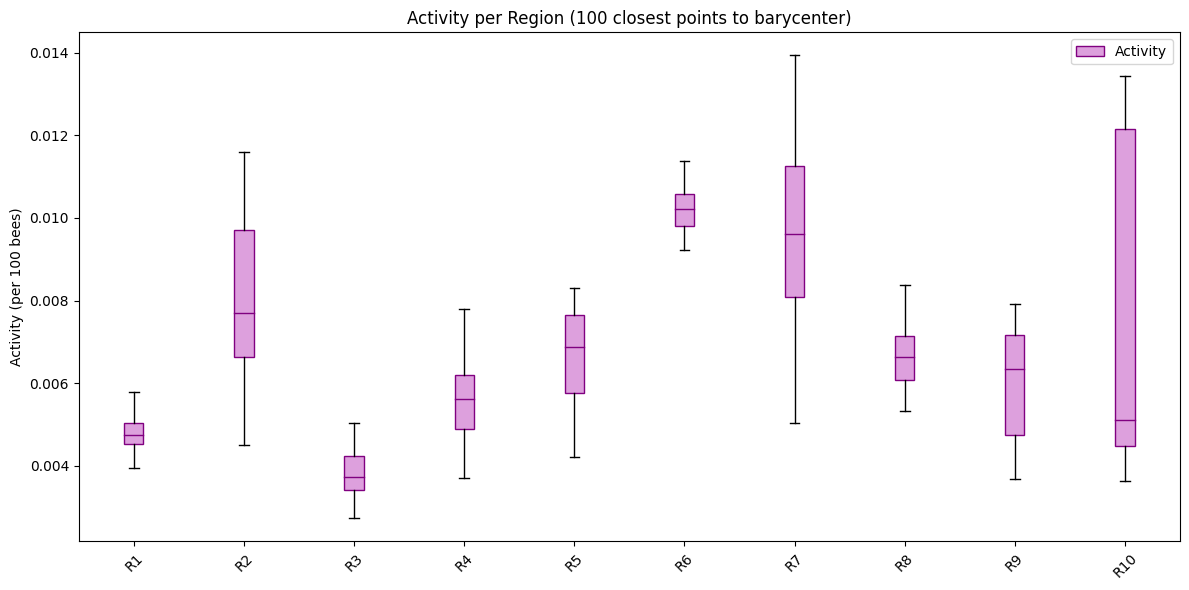

In [37]:
region_ids = sorted(closest_per_region.keys())

activity_data = []
labels = []
activity_ylabel = f"Activity (per {bee_scale} bees)" if use_bee_scaled_activity else "Activity (%)"

for rid in region_ids:
    df_r = closest_per_region[rid]
    if "activity" in df_r.columns:
        values = df_r["activity"].dropna().values
        if not use_bee_scaled_activity:
            values = values * 100.0
        activity_data.append(values)
    else:
        activity_data.append([np.nan])
    labels.append(f"R{rid}")

x = np.arange(len(region_ids))

fig, ax = plt.subplots(figsize=(12, 6))

bp_act = ax.boxplot(
    activity_data,
    positions=x,
    widths=w if "w" in globals() else 0.35,
    patch_artist=True,
    boxprops=dict(facecolor="plum", edgecolor="purple"),
    medianprops=dict(color="purple"),
    showfliers=False
)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.set_ylabel(activity_ylabel)
ax.set_title("Activity per Region (100 closest points to barycenter)")
ax.legend([bp_act["boxes"][0]], ["Activity"])

plt.tight_layout()
plt.show()

Day/Night Count

Region 1: day=17, night=83, total=100
Region 2: day=42, night=58, total=100
Region 3: day=43, night=57, total=100
Region 4: day=47, night=53, total=100
Region 5: day=72, night=28, total=100
Region 6: day=73, night=27, total=100
Region 7: day=48, night=52, total=100
Region 8: day=20, night=80, total=100
Region 9: day=62, night=38, total=100
Region 10: day=32, night=68, total=100


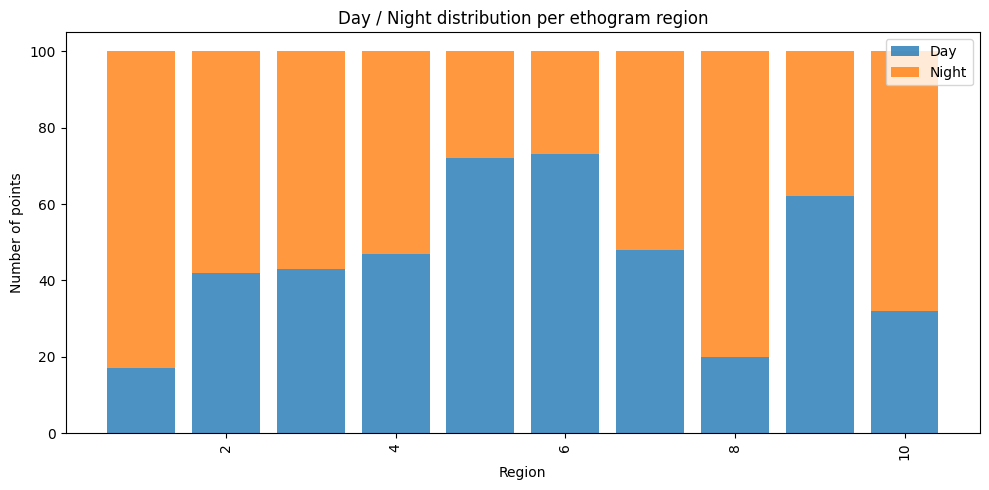

In [38]:
def is_day(ts):
    """Jour = 08:00 → 20:00 (inclus 8h, exclu 20h)"""
    hour = ts.hour
    return 8 <= hour < 20

day_night_counts = {}

for rid, df_r in closest_per_region.items():

    # --- Selest timestamp according to index type ---
    if isinstance(df_r.index, pd.MultiIndex):
        ts = df_r.index.get_level_values("timestamp")
    else:
        ts = df_r.index

    ts = pd.to_datetime(ts)

    # Series to allow .map()
    ts_series = pd.Series(ts)

    # day / night
    is_day_mask = ts_series.map(is_day).astype(bool)

    n_day = int(is_day_mask.sum())
    total = len(ts_series)
    n_night = int(total - n_day)

    day_night_counts[rid] = {
        "day": n_day,
        "night": n_night,
        "total": total
    }

# Print
for rid, c in day_night_counts.items():
    print(f"Region {rid}: day={c['day']}, night={c['night']}, total={c['total']}")
    
df_day_night = (
    pd.DataFrame.from_dict(day_night_counts, orient="index")
    .reset_index()
    .rename(columns={"index": "region"})
    .sort_values("region")
)

# Plot 

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    df_day_night["region"],
    df_day_night["day"],
    label="Day",
    alpha=0.8
)

ax.bar(
    df_day_night["region"],
    df_day_night["night"],
    bottom=df_day_night["day"],
    label="Night",
    alpha=0.8
)

ax.set_xlabel("Region")
ax.set_ylabel("Number of points")
ax.set_title("Day / Night distribution per ethogram region")

ax.legend()
ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

## Plot 10 points around barycentre

In [39]:
k = 10
rows = []

for region_id, bary in barycenters.items():
    df_r = df_nat[df_nat["region"] == region_id]
    if df_r.empty:
        continue

    coords = np.vstack(df_r["UMAP"].values).astype(float)
    dists = np.linalg.norm(coords - np.asarray(bary, dtype=float), axis=1)

    # index of the k nearest points
    k_eff = min(k, len(df_r))
    idx_topk = np.argsort(dists)[:k_eff]

    for rank, idx in enumerate(idx_topk, start=1):
        row = df_r.iloc[idx]

        real_ts = pd.to_datetime(row["real_timestamp"]) if "real_timestamp" in df_r.columns else pd.to_datetime(df_r.index[idx])
        source_id = row["source_id"] if "source_id" in df_r.columns else None

        row_dict = {
            "region": int(region_id),
            "rank": int(rank),                
            "distance": float(dists[idx]),
            "real_timestamp": real_ts,
            "source_id": source_id,
        }
        
        # copy all other useful columns (sensors, etc.), except UMAP and region
        for col in df_nat.columns:
            if col not in ["UMAP", "region"]:
                row_dict[col] = row[col]

        rows.append(row_dict)

df_region_top_ranks = (
    pd.DataFrame(rows)
    .set_index(["region", "rank"])
    .sort_index()
)


In [40]:
# temp columns
temp_cols = [c for c in df_nat.columns if c.startswith("t") and c[1:].isdigit()]
temp_cols = sorted(temp_cols)

# Falls back to Tamb if no per-sensor grid is present, and skips the plot entirely if neither
# exists (include_temperature=False).
use_tamb = False
have_temperature = True
if not temp_cols:
    if "Tamb" in df_nat.columns:
        use_tamb = True
        print("No per-sensor temperature columns ('tXX') found. Falling back to ambient temperature ('Tamb').")
    else:
        have_temperature = False
        print("No temperature columns ('tXX' or 'Tamb') found (include_temperature=False) -- skipping the temperature plot.")

if not have_temperature:
    pass

elif use_tamb:
    # --- Ambient temperature per rank (single sensor, one point per closest-point rank) ---
    ymin = df_region_top_ranks["Tamb"].min()
    ymax = df_region_top_ranks["Tamb"].max()

    for region_id in df_region_top_ranks.index.get_level_values("region").unique():

        df_r10 = df_region_top_ranks.loc[region_id]   # index = rank (1..10)

        plt.figure(figsize=(6, 4))
        plt.bar(df_r10.index.astype(str), df_r10["Tamb"].astype(float))
        plt.ylim(ymin, ymax)

        plt.xlabel("Rank (closest to barycenter)")
        plt.ylabel("Ambient temperature (°C)")
        plt.title(f"Region {region_id} — Tamb for the 10 closest points to barycenter")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

else:
    # same scale
    ymin = df_region_top_ranks[temp_cols].min().min()
    ymax = df_region_top_ranks[temp_cols].max().max()

    x = np.arange(len(temp_cols))

    for region_id in df_region_top_ranks.index.get_level_values("region").unique():

        df_r10 = df_region_top_ranks.loc[region_id]   # index = rank (1..10)

        plt.figure(figsize=(10, 4))

        for rank, row in df_r10.iterrows():
            temps = row[temp_cols].values.astype(float)
            plt.plot(x, temps, marker='o', linewidth=1, label=f"rank {rank}")

        plt.xticks(x, temp_cols, rotation=90, fontsize=7)
        plt.ylim(ymin, ymax)

        plt.xlabel("Temperature sensors")
        plt.ylabel("Temperature (°C)")
        plt.title(f"Region {region_id} — 10 closest points to barycenter")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

No temperature columns ('tXX' or 'Tamb') found (include_temperature=False) -- skipping the temperature plot.
